## Installs

In [ ]:
# We can just use the standard pip install now!
!pip install playground mujoco_mjx brax mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 149.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 150.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 155.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.4/136.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 29.0 MB/s eta 0:00:00


In [ ]:
!pip install jaxued flax chex optax distrax wandb orbax-checkpoint

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.7/312.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.6/86.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 156.3 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=

## Imports

In [ ]:
# ==========================================
# 1. Standard Libraries & Environment Setup
# ==========================================
import os
import time
import datetime
import json
import shutil
from enum import IntEnum
from typing import Tuple, Any
import gc

# CRITICAL: Set MuJoCo's graphics backend to EGL for headless GPU rendering
# This MUST happen before importing mujoco or mediapy
os.environ['MUJOCO_GL'] = 'egl'


# ==========================================
# 2. JAX & The Monkey Patch
# ==========================================
import jax
import jax.numpy as jnp
import jax.tree_util

# CRITICAL: Apply the patch BEFORE importing jaxued or flax.
# Older libraries look for 'tree_multimap' during their initialization.
jax.tree_map = jax.tree_util.tree_map
if not hasattr(jax, 'tree_multimap'):
    jax.tree_multimap = jax.tree_util.tree_map


# ==========================================
# 3. Core Machine Learning & Logging Libraries
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import wandb
import chex
import optax
import distrax
import orbax.checkpoint as ocp

# Flax
from flax import struct
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
from flax.training.train_state import TrainState as BaseTrainState


# ==========================================
# 4. MuJoCo Physics & Visualization
# ==========================================
import mujoco
from mujoco import mjx
import mediapy as media


# ==========================================
# 5. JAXUED & MuJoCo Playground (Domain Specific)
# ==========================================
from jaxued.linen import ResetRNN
from jaxued.environments import UnderspecifiedEnv
from jaxued.level_sampler import LevelSampler
from jaxued.utils import compute_max_returns, max_mc, positive_value_loss

from mujoco_playground._src import mjx_env
from mujoco_playground._src.locomotion.go1 import joystick

# Ensure the 3D assets for the Go1 robot are downloaded
mjx_env.ensure_menagerie_exists()

print("Environment setup complete. All libraries imported successfully!")

mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [01:51<00:00]


Checking out commit 1b86ece576591213e2b666ebf59508454200ca97
Successfully downloaded mujoco_menagerie
Environment setup complete. All libraries imported successfully!


In [ ]:
# CHANGED
from google.colab import drive
# This will pop up a window asking for permission to access your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Go1_UED_Project_Final"

## Terrain Generation

In [ ]:
import jax
import jax.numpy as jnp

@jax.jit
def generate_interleaved_segment(params, key):
    """
    Option 1: Count = Subdivisions (Complexity), Severity = Height/Width (Intensity)
    16 cells along X (0.4m), 128 cells along Y (1.0m width)
    """
    p = jnp.clip(params, 0.0, 1.0)
    x_coords = jnp.arange(16)
    terrain = jnp.full((16, 128), 0.0)

    # ---------------------------------------------------------
    # 1. HURDLES -> PIPE GRIDS (Safely Widened, No Overlap)
    # ---------------------------------------------------------
    num_hurdles = jnp.where(p[0] > 0.66, 3, jnp.where(p[0] > 0.33, 2, jnp.where(p[0] > 0.0, 1, 0)))

    # Perfectly spaced, 2-cell wide hurdles with ZERO overlapping coordinates!
    is_h1 = (num_hurdles == 1) & ((x_coords == 7) | (x_coords == 8))
    is_h2 = (num_hurdles == 2) & ((x_coords == 3) | (x_coords == 4) | (x_coords == 11) | (x_coords == 12))
    is_h3 = (num_hurdles == 3) & ((x_coords == 2) | (x_coords == 3) | (x_coords == 7) | (x_coords == 8) | (x_coords == 12) | (x_coords == 13))

    is_hurdle = (is_h1 | is_h2 | is_h3) & (p[1] > 0.0)

    h_height = p[1] * 0.20
    terrain = jnp.where(is_hurdle[:, None], terrain + h_height, terrain)


    # ---------------------------------------------------------
    # 2. PLATFORMS -> SYMMETRIC PYRAMID STAIRS (Safety Capped)
    # ---------------------------------------------------------
    num_steps = jnp.where(p[2] > 0.66, 3.0, jnp.where(p[2] > 0.33, 2.0, 1.0))
    is_plat = (x_coords >= 3) & (x_coords <= 12) & (p[3] > 0.0)

    edge_dist = jnp.minimum(x_coords - 3, 12 - x_coords)
    step_width = 5.0 / num_steps
    step_idx = jnp.floor(edge_dist / step_width) + 1.0
    step_idx = jnp.clip(step_idx, 1.0, num_steps)

    step_multiplier = step_idx / num_steps

    # Capped at 0.25m total height!
    # Anything higher than 0.25m on a solid block causes the chest to tunnel.
    p_height = (p[3] * 0.25) * step_multiplier

    terrain = jnp.where(is_plat[:, None], terrain + p_height[:, None], terrain)

    # ---------------------------------------------------------
    # 3. GAPS -> PROGRESSIVE TRENCHES (Aligned Curriculum)
    # ---------------------------------------------------------
    # Complexity (p[4]): Controls the NUMBER of gaps (0, 1, or 2)
    # 0.0 to 0.33 -> 0 Gaps (Flat ground)
    # 0.33 to 0.66 -> 1 Gap (Centered)
    # 0.66 to 1.0 -> 2 Gaps (Requires a sequence of jumps)
    num_gaps = jnp.where(p[4] > 0.66, 2, jnp.where(p[4] > 0.33, 1, 0))

    # Intensity (p[5]): Controls the WIDTH of the gaps (1 to 4 cells)
    # 1 cell = 0.125m (A tiny step)
    # 4 cells = 0.5m (The absolute maximum realistic parkour leap for a Go1)
    gap_width_cells = jnp.where(p[5] > 0.75, 4,
                      jnp.where(p[5] > 0.50, 3,
                      jnp.where(p[5] > 0.25, 2,
                      jnp.where(p[5] > 0.00, 1, 0))))

    # --- MASK 1: SINGLE GAP (Centered in the segment) ---
    # Grows outward from the center (Cells 7 & 8)
    single_gap_mask = (
        ((gap_width_cells == 1) & (x_coords == 7)) |
        ((gap_width_cells == 2) & ((x_coords == 7) | (x_coords == 8))) |
        ((gap_width_cells == 3) & ((x_coords == 6) | (x_coords == 7) | (x_coords == 8))) |
        ((gap_width_cells == 4) & ((x_coords == 6) | (x_coords == 7) | (x_coords == 8) | (x_coords == 9)))
    )

    # --- MASK 2: DOUBLE GAPS (Spaced for a safe landing) ---
    # Gap A grows around Cell 3/4. Gap B grows around Cell 11/12.
    # Even at MAX difficulty (width=4), this leaves Cells 6, 7, 8, 9 untouched!
    # This creates a guaranteed 4-cell (0.5 meter) "Safe Island" in the middle to land on.
    double_gap_A = (
        ((gap_width_cells == 1) & (x_coords == 3)) |
        ((gap_width_cells == 2) & ((x_coords == 3) | (x_coords == 4))) |
        ((gap_width_cells == 3) & ((x_coords == 2) | (x_coords == 3) | (x_coords == 4))) |
        ((gap_width_cells == 4) & ((x_coords == 2) | (x_coords == 3) | (x_coords == 4) | (x_coords == 5)))
    )

    double_gap_B = (
        ((gap_width_cells == 1) & (x_coords == 12)) |
        ((gap_width_cells == 2) & ((x_coords == 11) | (x_coords == 12))) |
        ((gap_width_cells == 3) & ((x_coords == 11) | (x_coords == 12) | (x_coords == 13))) |
        ((gap_width_cells == 4) & ((x_coords == 10) | (x_coords == 11) | (x_coords == 12) | (x_coords == 13)))
    )

    double_gap_mask = double_gap_A | double_gap_B

    # Apply the logic based on the requested number of gaps
    is_actual_gap = ((num_gaps == 1) & single_gap_mask) | ((num_gaps == 2) & double_gap_mask)

    # Carve the gaps into the terrain (-1.0 meters deep)
    terrain = jnp.where(is_actual_gap[:, None], -1.0, terrain)


    # ---------------------------------------------------------
    # 4. HILLS & SLALOM
    # ---------------------------------------------------------
    # Hills
    num_waves = jnp.where(p[6] > 0.5, 2.0, jnp.where(p[6] > 0.0, 1.0, 0.0))
    phase = x_coords * (2.0 * jnp.pi * num_waves / 16.0)
    hill_amp = p[7] * 0.3
    wave = (1.0 - jnp.cos(phase)) * (hill_amp / 2.0) * (num_waves > 0)
    terrain = terrain + wave[:, None]

    return terrain


@jax.jit
def blueprint_to_track(blueprint_8x10, key):
    """8 segments × 16 cells = 128 cells along X → final 128×128 grid."""
    keys_8 = jax.random.split(key, 8)
    segments = jax.vmap(generate_interleaved_segment)(blueprint_8x10, keys_8)
    # segments: (8, 16, 128)
    terrain = segments.reshape(128, 128)  # (X=128, Y=128)

    # carve narrow bridge
    track_width = 40
    center_y = 64
    terrain = terrain.at[:, :center_y - (track_width // 2)].set(-1.0)
    terrain = terrain.at[:, center_y + (track_width // 2):].set(-1.0)

    return terrain

In [ ]:
@jax.jit
def enforce_clean_obstacles(blueprint, key):
    """
    Forces only ONE obstacle type to exist per segment by random selection.
    Blueprint structure: [h_prob, h_hgt, p_prob, p_hgt, g_prob, g_wid, hill_prob, hill_amp, s_cnt, s_gap]
    """
    # 1. Randomly pick an integer between 0 and 4 for each of the 8 segments
    dominant_idx = jax.random.randint(key, shape=(8,), minval=0, maxval=4)

    # 2. Create a one-hot mask for the dominant type. Shape: (8, 5)
    # Example: If Hurdles (0) are chosen, row is [1, 0, 0, 0, 0]
    type_mask = jax.nn.one_hot(dominant_idx, 4)

    full_mask_8 = jnp.repeat(type_mask, 2, axis=-1)

    # 3. Duplicate the mask so it covers BOTH parameters for each obstacle. Shape: (8, 10)
    # Now Hurdles mask looks like [1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
    full_mask = jnp.concatenate(
        [full_mask_8, jnp.zeros((8, 2), dtype=full_mask_8.dtype)],
        axis=-1
    )

    # 4. Multiply the raw blueprint by the mask to zero out the unselected obstacles
    return blueprint * full_mask

## ACCEL Blueprint mutator

In [ ]:
def sample_blueprint(key):
    key_gen, key_mask = jax.random.split(key)

    # 1. DECOUPLE THE LIMITS
    # Even Indices (Probs/Counts): Force high density [0.5 to 1.0] so they don't vanish!
    # Odd Indices (Heights/Widths): Force low severity [0.0 to 0.6] for the "Warm Start"

    min_vals = jnp.array([0.5, 0.0,  0.5, 0.0,  0.5, 0.0,  0.5, 0.0,  0.0, 0.0])
    max_vals = jnp.array([1.0, 0.6,  1.0, 0.6,  1.0, 0.6,  1.0, 0.6,  0.0, 0.0])

    # 2. GENERATE THE TRACK
    raw_blueprint = jax.random.uniform(key_gen, shape=(8, 10), minval=min_vals, maxval=max_vals)

    # 3. APPLY THE "ONE OBSTACLE PER SEGMENT" RULE
    return enforce_clean_obstacles(raw_blueprint, key_mask)


@jax.jit
def mutate_blueprint(key, blueprint, num_edits=1):
    key_noise, _ = jax.random.split(key)

    # 1. INFER THE PARENT'S MASK:
    # Reshape the parent blueprint to (8 segments, 5 obstacle types, 2 parameters)
    reshaped = blueprint.reshape((8, 5, 2))

    # Sum the two parameters for each obstacle type.
    # If the sum > 0, that obstacle type was "Active" in the parent track.
    active_types = jnp.sum(reshaped, axis=2, keepdims=True) > 0.0

    # Expand the mask to cover both parameters (e.g., both probability and height). Shape: (8, 10)
    full_mask = jnp.repeat(active_types, 2, axis=2).reshape((8, 10))

    # 2. GENERATE THE NOISE:
    # We only want to apply noise to the ACTIVE parameters!
    noise = jax.random.normal(key_noise, shape=blueprint.shape) * (0.1 * num_edits)

    # Multiply noise by the mask so we don't accidentally add noise to the inactive obstacles
    masked_noise = noise * full_mask.astype(jnp.float32)

    # 3. APPLY THE NOISE:
    # Add the masked noise to the parent blueprint and clip it
    mutated = jnp.clip(blueprint + masked_noise, 0.0, 1.0)

    # 4. SAFETY CHECK:
    # What if the additive noise accidentally pushed an active obstacle all the way down to 0.0?
    # If we let it stay 0.0, the segment becomes permanently dead (the ratcheting bug).
    # We force the probability parameter (even indices: 0, 2, 4, 6, 8) to have a minimum value
    # of 0.1 ONLY if it is supposed to be the active obstacle.

    # Create an array of alternating [0.1, 0.0, 0.1, 0.0...] to target only the probabilities
    min_prob_enforcer = jnp.tile(jnp.array([0.1, 0.0]), 5)

    # Apply the enforcer only to the active mask locations
    safe_minimums = full_mask.astype(jnp.float32) * min_prob_enforcer

    # Ensure the mutated track respects these minimums
    mutated = jnp.maximum(mutated, safe_minimums)

    # 5. PROTECT SEGMENT 0:
    # Force the starting segment to always be perfectly flat
    mutated = mutated.at[0].set(0.0)

    mutated = mutated.at[:, 8:10].set(0.0)

    return mutated

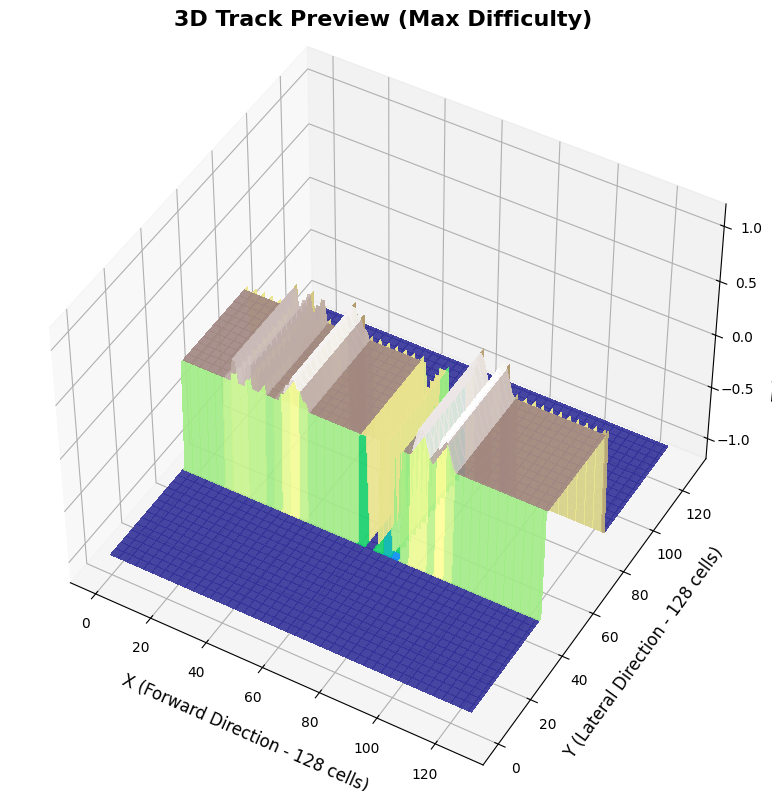

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

# Ensure blueprint_to_track and generate_interleaved_segment are loaded

def plot_3d_track_preview():
    key = jax.random.PRNGKey(42)

    # We will hand-craft an 8x10 blueprint to showcase the max difficulty
    # of each obstacle type across the track!
    blueprint = jnp.zeros((8, 10))

    # Seg 0: Flat (Starting zone)
    # Seg 1: 4-Pipe Grid (p[0]=1.0, p[1]=1.0)
    blueprint = blueprint.at[1].set(jnp.array([1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]))
    # Seg 2: 3-Step Stairs (p[2]=1.0, p[3]=1.0)
    blueprint = blueprint.at[2].set(jnp.array([0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]))
    # Seg 3: Flat recovery
    # Seg 4: Stepping Stones / Max Gap (p[4]=1.0, p[5]=1.0)
    blueprint = blueprint.at[4].set(jnp.array([0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]))
    # Seg 5: Max Hills (p[6]=1.0, p[7]=1.0)
    blueprint = blueprint.at[5].set(jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0]))
    # # Seg 6: Slalom Doors (p[8]=1.0, p[9]=1.0)
    # blueprint = blueprint.at[6].set(jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0]))

    # Generate the 128x128 track
    track = blueprint_to_track(blueprint, key)
    track_np = np.array(track)

    # Set up 3D plot
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create X, Y meshgrid
    X, Y = np.meshgrid(np.arange(128), np.arange(128))

    # Plot the surface. We transpose track_np so the forward X-axis goes left-to-right
    surf = ax.plot_surface(X, Y, track_np.T, cmap='terrain',
                           linewidth=0, antialiased=False, alpha=0.9)

    ax.set_title("3D Track Preview (Max Difficulty)", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (Forward Direction - 128 cells)", fontsize=12, labelpad=10)
    ax.set_ylabel("Y (Lateral Direction - 128 cells)", fontsize=12, labelpad=10)
    ax.set_zlabel("Z (Height - meters)", fontsize=12, labelpad=10)

    # Adjust viewing angle (Elev=elevation, Azim=rotation)
    ax.view_init(elev=45, azim=-60)

    # Limit Z-axis to make the obstacles pop without looking like skyscrapers
    ax.set_zlim(-1.2, 1.2)

    plt.tight_layout()
    plt.show()

plot_3d_track_preview()

## Environment Wrappers

In [ ]:
class DynamicJoystick(joystick.Joystick):
    """
    A lightweight subclass of the Go1 Joystick env that allows
    us to inject custom terrain models on the fly for jaxued.
    """

    def reset_with_model(self, rng, dynamic_mjx_model):
        # 1. Save the original static model
        original_model = self._mjx_model

        # 2. Temporarily replace it with our dynamic (and potentially batched) model
        self._mjx_model = dynamic_mjx_model

        # 3. Call the base class's standard reset method.
        # Under the hood, it will now use our dynamic model to compute physics!
        state = self.reset(rng)

        # 4. Restore the original model to keep the Python object clean
        self._mjx_model = original_model

        return state

    def step_with_model(self, dynamic_mjx_model, state, action):
        # Apply the exact same trick for the step function
        original_model = self._mjx_model
        self._mjx_model = dynamic_mjx_model

        next_state = self.step(state, action)

        self._mjx_model = original_model

        return next_state

In [ ]:
@struct.dataclass
class Go1EnvParams:
    # The training/eval loop expects this specific name:
    max_steps_in_episode: int = 1500     # PARAMS

    # We'll keep this one too, just in case other parts of the base env use it:
    max_steps_per_episode: int = 1500    # PARAMS

    # Standard MuJoCo Playground parameters
    terminate_when_unhealthy: bool = True
    realign_to_center: bool = True

@struct.dataclass
class Go1State:
    base_state: Any  # This holds the MuJoCo/MJX physics data
    hfield_data: jax.Array  # This holds the 1D flattened terrain array
    last_action: jnp.ndarray

In [ ]:
class Go1RoughUED(UnderspecifiedEnv):
    def __init__(self, base_env, nrow=256, ncol=256, z_min=-1.0, z_max=2.0):
        self.base_env = base_env
        self.nrow = nrow
        self.ncol = ncol
        self.action_size = self.base_env.action_size

        # CHANGED: Mute native command-tracking to allow custom directional injection
        if hasattr(self.base_env.unwrapped, 'reward_scales'):
            scales = self.base_env.unwrapped.reward_scales

            # Mute overlaps
            if 'tracking_lin_vel' in scales: scales['tracking_lin_vel'] = 0.0
            if 'tracking_ang_vel' in scales: scales['tracking_ang_vel'] = 0.0
            if 'stand_still' in scales: scales['stand_still'] = 0.0

            if 'termination' in scales: scales['termination'] = 0.0
            if 'pose' in scales: scales['pose'] = 0.0

        # 1. Centralize the Z-span logic
        self.z_min = z_min
        self.z_max = z_max
        self.z_span = self.z_max - self.z_min

        # 2. Fix the MuJoCo model dimensions ONCE, right here
        mj_model = self.base_env.unwrapped.mj_model
        mj_model.hfield_size[0, 0] = 20.0  # Track length
        mj_model.hfield_size[0, 1] = 4.0   # Track width
        mj_model.hfield_size[0, 2] = self.z_span

        # Strip floor material and force bright grey (for better rendering)
        mj_model.geom_matid[0] = -1
        mj_model.geom_rgba[0] = [0.7, 0.7, 0.7, 1.0]

        # Push the correctly scaled model back to the MJX environment
        self.base_env.unwrapped._mjx_model = mjx.put_model(mj_model)

    @property
    def default_params(self) -> Go1EnvParams:
        return Go1EnvParams()

    def _generate_hfield(self, key, blueprint):
        # ---> BASELINE 1 & 2 OVERRIDE <---
        # We completely ignore the 'blueprint' vector and force the
        # terrain to be a perfectly flat sheet at Z = 0.0

        # Create an array of zeros matching the required hfield dimensions
        flat_terrain = jnp.zeros((self.nrow, self.ncol))

        # We must still normalize it according to the z_min and z_span
        # logic that MuJoCo XLA expects, otherwise the robot will spawn
        # in the air or under the floor!
        normalized = (flat_terrain - self.z_min) / self.z_span

        # Return the flattened array just like the original function did
        return jnp.clip(normalized, 0.0, 1.0).T.flatten()

    def reset_to_level(self, key, level, params):
        rng_terrain, rng_reset = jax.random.split(key)

        flat_hfield = self._generate_hfield(rng_terrain, level)
        temp_model = self.base_env.unwrapped._mjx_model.replace(hfield_data=flat_hfield)
        base_state = self.base_env.reset_with_model(rng_reset, temp_model)

        # Custom Spawn Location: Drop from slightly above the terrain
        # The track spans from X = -20.0 to X = +20.0.
        # We spawn at -18.0 to give the robot a clean 2-meter flat runway before obstacles.
        new_qpos = base_state.data.qpos.at[0].set(-18.0)
        # CHANGED Center it on the Y axis
        new_qpos = new_qpos.at[1].set(0.0)
        # Slide the robot to find the true physical center of the track
        # Try 2.0, 3.0, -2.0, or -3.0 until it sits perfectly in the middle!
        # new_qpos = new_qpos.at[1].set(-0.2)
        # The Go1 is ~0.35m tall and the start line is flat (Z=0.0).
        # Spawning at 0.4m gives it a gentle, perfectly safe touchdown.
        max_obstacle_height = jnp.max(level)
        safe_z_height = max_obstacle_height + 0.4

        new_qpos = new_qpos.at[2].set(1.4)
        # new_qpos = new_qpos.at[2].set(0.4)

        # # ---> CHANGED: THE SPAWN ORIENTATION FIX <---
        # # MuJoCo quaternions are [w, x, y, z].
        # # [1, 0, 0, 0] is default. [0, 0, 0, 1] is a 180-degree rotation around the Z-axis.
        # new_qpos = new_qpos.at[3:7].set(jnp.array([0.0, 0.0, 0.0, 1.0]))

        # ==========================================================
        # ---> CHANGED THE ORIENTATION FIX <---
        # If [0, 0, 0, 1] didn't work, try [1.0, 0.0, 0.0, 0.0] here!
        new_qpos = new_qpos.at[3:7].set(jnp.array([1.0, 0.0, 0.0, 0.0]))
        # We step the environment with an empty action just to trigger the sensor update
        # dummy_action = jnp.zeros(self.action_size)
        # ==========================================================

        # Update the physics data with the new position
        new_data = base_state.data.replace(qpos=new_qpos)

        # Run one quick kinematics update so the simulator registers the new position
        new_data = mjx.kinematics(temp_model, new_data)
        base_state = base_state.replace(data=new_data)

        # Initialize last_action to zeros on reset
        initial_last_action = jnp.zeros(self.action_size)

        state = Go1State(base_state=base_state, hfield_data=flat_hfield, last_action=initial_last_action)
        return base_state.obs, state


    ## CHANGED: UPDATED 'REWARD SHAPING TO BE SAME AS ORIGINAL MUJOCO_PLAYGROUND ONE BUT WITH UPDATES
    ## FOR OUR SPECIFIC SCENARIO AND TO ALIGN W/ BASELINES 1 & 3; added back drift penalties (y, yaw)
    def step(self, key, state, action, params):
        temp_model = self.base_env.unwrapped._mjx_model.replace(hfield_data=state.hfield_data)
        next_base_state = self.base_env.step_with_model(temp_model, state.base_state, action)

        # --------------------------------------------------
        # 1. EXTRACT DEEPMIND KINEMATIC SHAPING
        # --------------------------------------------------
        # (tracking_lin_vel is muted to 0.0 in __init__)
        dense_reward = next_base_state.reward

        # --------------------------------------------------
        # 2. INJECT THE IDENTICAL "TASK PACKAGE"
        # --------------------------------------------------

        # ---------------------------------------------------------
        # 1. Forward Velocity (Target Tracking: 4 km/hr)
        # ---------------------------------------------------------
        raw_v_x = next_base_state.data.qvel[0]

        # Max reward is +2.5 per step. No reward for walking backward.
        directional_bonus = 1.0 * jnp.clip(raw_v_x, 0.0, 2.5)

        # ---------------------------------------------------------
        # 2. Lateral Drift (The "Electric Fence")
        # ---------------------------------------------------------
        # Track is ~4m wide. Give a 2m wide safe zone (y = -1.0 to 1.0).
        # It can wander freely here. Outside 1.0, the penalty goes exponential.
        y_pos = next_base_state.data.qpos[1]

        # 1. Gentle pull towards the center (like before)
        gentle_center = jnp.square(y_pos)

        # 2. The Electric Fence: Kicks in ONLY if it drifts past 0.8 meters left or right.
        # The * 10.0 multiplier makes this a massive, terrifying wall to the neural network.
        edge_panic = jnp.square(jnp.maximum(0.0, jnp.abs(y_pos) - 0.8)) * 10.0

        centering_penalty = gentle_center + edge_panic

        # Punish sliding sideways like a crab
        v_y = next_base_state.data.qvel[1]
        strafe_penalty = jnp.square(v_y)

        # ---------------------------------------------------------
        # 3. Posture (Free the Pitch!)
        # ---------------------------------------------------------
        # Quaternions: [qw, qx, qy, qz] -> Indices: [3, 4, 5, 6]
        # qx (Index 4) = Roll (tilting side-to-side)
        # qz (Index 6) = Yaw (spinning like a top)
        # qy (Index 5) = Pitch. WE IGNORE THIS SO IT CAN REAR UP AND CLIMB!
        qx = next_base_state.data.qpos[4]
        qz = next_base_state.data.qpos[6]
        posture_penalty = jnp.square(qx) + jnp.square(qz)

        yaw_rate = next_base_state.data.qvel[5]
        yaw_penalty = jnp.square(yaw_rate)

        # ---------------------------------------------------------
        # 4. Action Smoothing (Loose enough to leap)
        # ---------------------------------------------------------
        # These are kept low enough that the robot is allowed to make
        # the sudden, explosive leg snaps required to jump over a hurdle.
        action_penalty = jnp.sum(jnp.square(action))
        action_rate_penalty = jnp.sum(jnp.square(action - state.last_action))

        # ---------------------------------------------------------
        # 5. The "Lazy Penalty" (The Stick)
        # ---------------------------------------------------------
        # If it stops moving (e.g., resting its nose against a wall), it bleeds points.
        # This actively forces it to jump to escape the penalty!
        lazy_penalty = jnp.where(raw_v_x < 0.2, -1.0, 0.0)

        # ---> ADD THIS: The Heading Penalty <---
        # qz (Index 6) is the Yaw quaternion. When facing perfectly forward, qz is 0.0.
        qz = next_base_state.data.qpos[6]
        heading_penalty = jnp.square(qz)

        # ---------------------------------------------------------
        # 6. Assemble Custom Reward
        # ---------------------------------------------------------
        custom_reward = (
            directional_bonus
            - (2.0 * centering_penalty)         # Massive weight for the Electric Fence!
            - (0.05 * strafe_penalty)
            - (1.0 * posture_penalty)        # Keeps spine upright but allows pitching
            - (0.05 * yaw_penalty)
            + lazy_penalty
        )

        # ---------------------------------------------------------
        # 7. Calculate Termination
        # ---------------------------------------------------------
        # Extract the local UP vector (Z-axis) from the quaternion to check if flipped
        x = next_base_state.data.qpos[4]
        y = next_base_state.data.qpos[5]
        up_z = 1.0 - 2.0 * (x**2 + y**2)
        is_flipped = up_z < 0.5

        # Check if it fell into a deep pit
        z_pos = next_base_state.data.qpos[2]
        fell_in_gap = z_pos < (self.z_min + 0.15)

        is_fallen = jnp.logical_or(is_flipped, fell_in_gap)

        # Check if it crossed the finish line
        x_pos = next_base_state.data.qpos[0]
        reached_goal = x_pos > 19.0

        done = jnp.logical_or(next_base_state.done, is_fallen)
        done = jnp.logical_or(done, reached_goal)

        # ---------------------------------------------------------
        # 8. Apply Final Reward (No Alive Bonus!)
        # ---------------------------------------------------------
        # If it falls, it gets a flat -10.0 (death is painful).
        # If it reaches the goal, it gets a +10.0 bonus!
        final_reward = jnp.where(is_fallen, -10.0, custom_reward + dense_reward)
        final_reward = jnp.where(reached_goal, custom_reward + dense_reward + 10.0, final_reward)

        # Update state, remembering the action for the next step's rate penalty
        next_state = Go1State(base_state=next_base_state, hfield_data=state.hfield_data, last_action=action)
        return next_base_state.obs, next_state, final_reward, done, next_base_state.info

In [ ]:
## CHANGED: Added the training-time course generator (to not be 'no obstacle, flat' terrains unlike the 'training' tracks/courses)
class Go1RoughUED_Eval(Go1RoughUED):
    """
    Evaluation environment: Renders physical obstacles for evaluation tests.
    """
    def _generate_hfield(self, key, blueprint):
        # ---> CHANGED: The ACCEL "Spawn-Kill" Protection <---
        # Forcefully overwrite Segment 0 to be perfectly flat (all zeros)
        # This guarantees the robot always spawns on safe ground!
        blueprint = blueprint.at[0].set(0.0)
        # ----------------------------------------------------
        low_res = blueprint_to_track(blueprint, key)

        row_scale = max(1, self.nrow // low_res.shape[0])
        col_scale = max(1, self.ncol // low_res.shape[1])
        terrain_scaled = jnp.kron(low_res, jnp.ones((row_scale, col_scale)))
        terrain_scaled = terrain_scaled[:self.nrow, :self.ncol]

        # Use the centralized variables!
        normalized = (terrain_scaled - self.z_min) / self.z_span
        return jnp.clip(normalized, 0.0, 1.0).T.flatten()

In [ ]:
#@title Temp: Check Reward Components Config for the Full Shaping Ssetup
# import jax
# import jax.numpy as jnp

# print("=========================================================")
# print(" 🕵️ DEEPMIND REWARD FORENSICS: BASELINE 2")
# print("=========================================================")

# # 1. Spin up the environment
# rng = jax.random.PRNGKey(42)
# rng_reset, rng_step = jax.random.split(rng)

# base_env = DynamicJoystick(task="rough_terrain")
# env = Go1RoughUED(base_env, nrow=256, ncol=256)
# env_params = env.default_params

# # 2. Reset the environment (using a flat 10D blueprint)
# blueprint = jnp.zeros(10)
# obs, state = env.reset_to_level(rng_reset, blueprint, env_params)

# # 3. Take a single step with a dummy action (all joints at 0)
# action = jnp.zeros(env.action_size)
# next_obs, next_state, reward, done, info = env.step(rng_step, state, action, env_params)

# # 4. Extract the base state to see what MuJoCo actually calculated
# base_state = next_state.base_state

# print(f"Total Dense Reward Computed: {base_state.reward}")
# print("-" * 57)

# # 5. Search the metrics dictionary for the underlying reward components
# reward_keys_found = False
# if hasattr(base_state, 'metrics'):
#     print("Metrics dictionary found! Searching for reward components...\n")
#     for key, value in base_state.metrics.items():
#         if 'reward' in key.lower():
#             print(f"  {key:<30} | Value: {value}")
#             reward_keys_found = True
# else:
#     print("CRITICAL: No metrics dictionary found on base_state!")

# if not reward_keys_found:
#     print("\n🚨 ALERT: No active reward components found in the metrics!")
#     print("This means Baseline 2 is likely running with ZERO shaping rewards!")
# else:
#     print("\n✅ SUCCESS: The 16 reward components are active in this notebook!")

# print("=========================================================")

In [ ]:
#@title Source DeepMind Rewards
# import inspect
# from mujoco_playground import registry

# # 1. Load the exact environment you are using
# base_env = registry.load("Go1JoystickRoughTerrain")

# # 2. Find out exactly where this file lives on your hard drive / Colab instance
# file_path = inspect.getfile(base_env.__class__)
# print(f"File lives at: {file_path}\n")
# print("-" * 50)

# # 3. Print the raw source code!
# source_code = inspect.getsource(base_env.__class__)
# print(source_code)

In [ ]:
#@title Testing if everything runs alright
# # 1. Initialize the environments
# base_joystick = DynamicJoystick(task="rough_terrain")
# ued_env = Go1RoughUED(base_joystick)

# # 2. Generate a dummy 8x10 blueprint
# rng = jax.random.PRNGKey(42)
# rng, key_blueprint = jax.random.split(rng)
# dummy_level = jax.random.uniform(key_blueprint, (8, 10), minval=0.0, maxval=1.0)

# # 3. Test the reset function (Jitting it to ensure it compiles!)
# jit_reset = jax.jit(ued_env.reset_to_level)
# obs, state = jit_reset(rng, dummy_level, ued_env.default_params)

# print("Observation structure:")
# print(jax.tree_util.tree_map(lambda x: x.shape, obs))

# # 4. Test the step function
# dummy_action = jnp.zeros(ued_env.action_size)
# jit_step = jax.jit(ued_env.step)
# next_obs, next_state, reward, done, info = jit_step(rng, state, dummy_action, ued_env.default_params)

# print("Step successful! Reward:", reward)

## Actor Critic Network

In [ ]:
class Go1ActorCritic(nn.Module):
    """
    A continuous Actor-Critic MLP with an LSTM core, designed for the Go1.
    """
    action_dim: int

    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs

        # privileged state contains all observations: proprioceptive and exteroceptive
        x = obs['privileged_state']

        # 2. Base MLP embedding
        embedding = nn.Dense(256, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="embed0")(x)
        embedding = nn.relu(embedding)

        # 3. Memory (LSTM)
        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        # 4. DECOUPLED ACTOR (Deeper)
        actor = nn.Dense(256, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(embedding)
        actor = nn.relu(actor)
        actor = nn.Dense(128, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(actor) # Extra layer!
        actor = nn.relu(actor)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0))(actor)

        actor_log_std = self.param('log_std', constant(-0.5), (self.action_dim,))
        pi = distrax.MultivariateNormalDiag(loc=actor_mean, scale_diag=jnp.exp(actor_log_std))

        # 5. DECOUPLED CRITIC (Deeper)
        critic = nn.Dense(256, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(128, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(critic) # Extra layer!
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)

    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))

In [ ]:
# === 1. STATE DEFINITIONS ===
class UpdateState(IntEnum):
    DR = 0
    REPLAY = 1

class TrainState(BaseTrainState):
    sampler: dict = struct.field(pytree_node=True)
    update_state: UpdateState = struct.field(pytree_node=True)
    num_dr_updates: int
    num_replay_updates: int
    num_mutation_updates: int
    dr_last_level_batch: chex.ArrayTree = struct.field(pytree_node=True)
    replay_last_level_batch: chex.ArrayTree = struct.field(pytree_node=True)
    mutation_last_level_batch: chex.ArrayTree = struct.field(pytree_node=True)

# === 2. GAE (ADVANTAGE ESTIMATION) ===
def compute_gae(gamma, lambd, last_value, values, rewards, dones):
    def compute_gae_at_timestep(carry, x):
        gae, next_value = carry
        value, reward, done = x
        delta = reward + gamma * next_value * (1 - done) - value
        gae = delta + gamma * lambd * (1 - done) * gae
        return (gae, value), gae

    _, advantages = jax.lax.scan(
        compute_gae_at_timestep,
        (jnp.zeros_like(last_value), last_value),
        (values, rewards, dones),
        reverse=True,
        unroll=16,
    )
    return advantages, advantages + values

# === 3. ROLLOUT TRAJECTORIES ===
def sample_trajectories_rnn(
    rng, env, env_params, train_state, init_hstate, init_obs, init_env_state, num_envs, max_episode_length
):
    def sample_step(carry, _):
        rng, train_state, hstate, obs, env_state, last_done = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_util.tree_map(lambda x: x[None, ...], (obs, last_done))
        hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = value.squeeze(0), action.squeeze(0), log_prob.squeeze(0)

        next_obs, env_state, reward, done, info = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

        # ---> FIX: Cast MuJoCo's float32 done flag to boolean <---
        done = done.astype(bool)

        carry = (rng, train_state, hstate, next_obs, env_state, done)
        return carry, (obs, action, reward, done, log_prob, value, info)

    (rng, train_state, hstate, last_obs, last_env_state, last_done), traj = jax.lax.scan(
        sample_step,
        (rng, train_state, init_hstate, init_obs, init_env_state, jnp.zeros(num_envs, dtype=bool)),
        None,
        length=max_episode_length,
        unroll=4
    )

    x = jax.tree_util.tree_map(lambda x: x[None, ...], (last_obs, last_done))
    _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)

    return (rng, train_state, hstate, last_obs, last_env_state, last_value.squeeze(0)), traj

# === 4. EVALUATION ROLLOUT ===
def evaluate_rnn(rng, env, env_params, train_state, init_hstate, init_obs, init_env_state, max_episode_length):
    num_levels = jax.tree_util.tree_leaves(init_obs)[0].shape[0]

    def step(carry, _):
        rng, hstate, obs, state, done, mask, episode_length = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_util.tree_map(lambda x: x[None, ...], (obs, done))
        hstate, pi, _ = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action).squeeze(0)

        obs, next_state, reward, done, _ = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_levels), state, action, env_params)

        # ---> FIX: Cast MuJoCo's float32 done flag to boolean <---
        done = done.astype(bool)

        next_mask = mask & ~done
        episode_length += mask

        return (rng, hstate, obs, next_state, done, next_mask, episode_length), (state, reward)

    (_, _, _, _, _, _, episode_lengths), (states, rewards) = jax.lax.scan(
        step,
        (rng, init_hstate, init_obs, init_env_state, jnp.zeros(num_levels, dtype=bool), jnp.ones(num_levels, dtype=bool), jnp.zeros(num_levels, dtype=jnp.int32)),
        None,
        length=max_episode_length,
    )

    return states, rewards, episode_lengths

# === 5. PPO UPDATE FUNCTION ===
def update_actor_critic_rnn(
    rng, train_state, init_hstate, batch, num_envs, n_steps, n_minibatch, n_epochs, clip_eps, entropy_coeff, critic_coeff, update_grad=True
):
    obs, actions, dones, log_probs, values, targets, advantages = batch

    # ---> CHANGED: Global Advantage Normalization <---
    # Normalize across the entire rollout batch (all envs, all steps)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
    batch = obs, actions, last_dones, log_probs, values, targets, advantages

    def update_epoch(carry, _):
        def update_minibatch(train_state, minibatch):
            init_hstate, obs, actions, last_dones, log_probs, values, targets, advantages = minibatch

            def loss_fn(params):
                _, pi, values_pred = train_state.apply_fn(params, (obs, last_dones), init_hstate)
                log_probs_pred = pi.log_prob(actions)
                entropy = pi.entropy().mean()

                ratio = jnp.exp(log_probs_pred - log_probs)
                l_clip = (-jnp.minimum(ratio * advantages, jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * advantages)).mean()

                values_pred_clipped = values + (values_pred - values).clip(-clip_eps, clip_eps)
                l_vf = 0.5 * jnp.maximum((values_pred - targets) ** 2, (values_pred_clipped - targets) ** 2).mean()

                loss = l_clip + critic_coeff * l_vf - entropy_coeff * entropy
                return loss, (l_vf, l_clip, entropy)

            grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
            loss, grads = grad_fn(train_state.params)
            if update_grad:
                train_state = train_state.apply_gradients(grads=grads)
            return train_state, loss

        rng, train_state = carry
        rng, rng_perm = jax.random.split(rng)
        permutation = jax.random.permutation(rng_perm, num_envs)

        minibatches = (
            jax.tree_util.tree_map(
                lambda x: jnp.take(x, permutation, axis=0).reshape(n_minibatch, -1, *x.shape[1:]),
                init_hstate,
            ),
            *jax.tree_util.tree_map(
                lambda x: jnp.take(x, permutation, axis=1).reshape(x.shape[0], n_minibatch, -1, *x.shape[2:]).swapaxes(0, 1),
                batch,
            ),
        )
        train_state, losses = jax.lax.scan(update_minibatch, train_state, minibatches)
        return (rng, train_state), losses

    return jax.lax.scan(update_epoch, (rng, train_state), None, n_epochs)

## Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import clear_output

os.makedirs("ued_history", exist_ok=True)

def plot_ued_dashboard(train_state, level_sampler, metrics, run_name="ACCEL"):
    """Creates a highly descriptive, locally saved live-updating dashboard."""
    clear_output(wait=True)

    # Increased figure size for better readability of text and colorbars
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # Extract the first blueprint from each batch (converting from JAX to NumPy)
    dr_level = np.array(train_state.dr_last_level_batch[0])
    replay_level = np.array(train_state.replay_last_level_batch[0])
    mut_level = np.array(train_state.mutation_last_level_batch[0])

    # Fetch the hardest level currently in the replay buffer
    highest_idx = train_state.sampler["scores"].argmax()
    highest_level = np.array(level_sampler.get_levels(train_state.sampler, highest_idx))

    # Helper function to format each subplot consistently
    def format_subplot(ax, data, title, subtitle, cmap='magma'):
        # origin='lower' ensures the start of the track is at the bottom/left
        im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1, origin='lower', aspect='auto')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

        # 1. Map the X-axis to your exact blueprint parameters
        param_names = [
            "Hurdle Cnt", "Hurdle Hgt",
            "Plat Cnt", "Plat Hgt",
            "Gap Cnt", "Gap Width",
            "Hill Freq", "Hill Amp",
            "Unused 1", "Unused 2"
        ]
        ax.set_xticks(range(10))
        ax.set_xticklabels(param_names, rotation=45, ha='right', fontsize=9)

        # 2. Map the Y-axis to show physical progression down the track
        progression_labels = [f"Seg {i}" for i in range(8)]
        progression_labels[0] = "Start (Seg 0)"
        progression_labels[7] = "End (Seg 7)"
        ax.set_yticks(range(8))
        ax.set_yticklabels(progression_labels, fontsize=9)

        # Add a descriptive subtitle below the X-axis (adjusted position for the rotated labels)
        ax.text(0.5, -0.35, subtitle, size=11, ha="center", transform=ax.transAxes, style='italic', color='dimgray')

        # Add a colorbar attached to the side of the plot
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Parameter Intensity (0.0 = Flat, 1.0 = Max)', rotation=270, labelpad=15)

        # Show faint grid lines to delineate the 8x10 cells
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True)
        ax.set_yticks(np.arange(-.5, 8, 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1.0, alpha=0.4)

    # Plot 1: Domain Randomization
    format_subplot(axes[0], dr_level, "1. Random Generation (DR)",
                   "Freshly sampled from uniform distribution.")

    # Plot 2: Replay Buffer
    format_subplot(axes[1], replay_level, "2. Replayed Level",
                   "Pulled from history due to high agent regret.")

    # Plot 3: Mutation
    format_subplot(axes[2], mut_level, "3. Mutated Child Level",
                   "Slightly altered replay level (ACCEL exploration).")

    # Plot 4: Highest Scoring (Frontier)
    format_subplot(axes[3], highest_level, "4. Hardest Discovered Level",
                   "Maximum regret score in current buffer.", cmap='viridis')

    # ---> CHANGED: Extract individual solve rates <---
    update_count = metrics.get('update_count', 0)

    # Get the raw arrays (converting from JAX to NumPy just to be safe)
    solve_rates_array = np.array(metrics.get('eval_solve_rates', [0.0, 0.0, 0.0]))

    # Safely extract Easy, Medium, Hard (handling cases where there might be fewer eval levels)
    easy_rate = solve_rates_array[0] * 100 if len(solve_rates_array) > 0 else 0.0
    med_rate = solve_rates_array[1] * 100 if len(solve_rates_array) > 1 else 0.0
    hard_rate = solve_rates_array[2] * 100 if len(solve_rates_array) > 2 else 0.0

    # Overall Title with the new breakdown
    title_str = (
        f"[{run_name}] Update: {int(update_count)} | "
        f"Solve Rates → Easy: {easy_rate:.1f}% | Med: {med_rate:.1f}% | Hard: {hard_rate:.1f}%"
    )

    plt.suptitle(title_str, fontsize=16, fontweight='bold', y=1.08)
    # ------------------------------------------------

    plt.tight_layout()

    # Save locally as a backup
    # Make sure SAVE_DIR is defined globally or pass it in!
    # filename = f"{SAVE_DIR}/{run_name}_update_{int(update_count):05d}.png"
    # plt.savefig(filename, dpi=100, bbox_inches='tight', facecolor='white')

    # Display in the notebook
    plt.show()

    # CRITICAL FIX: Close the figure to prevent Colab RAM memory leaks!
    plt.close(fig)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_curriculum_dashboard(train_state, run_name="ACCEL"):
    """Plots a multi-panel dashboard of the 10D replay buffer."""
    buffer_levels = np.array(train_state.sampler["levels"])

    # Ensure size is a scalar to prevent mask broadcasting issues
    buffer_size = int(np.array(train_state.sampler["size"]))
    valid_mask = np.arange(buffer_levels.shape[0]) < buffer_size

    active_levels = buffer_levels[valid_mask]
    if len(active_levels) == 0:
        print("Buffer is empty, cannot plot frontier yet.")
        return

    # ---> FIX 1: Reshape flattened levels (N, 80) to (N, 8, 10) <---
    if active_levels.ndim == 2 and active_levels.shape[1] == 80:
        active_levels = active_levels.reshape(-1, 8, 10)

    # Now correctly find the peak difficulty on the track (Shape becomes N, 10)
    max_params = active_levels.max(axis=1)

    # ---> FIX 2: Flatten scores and remove NaNs to prevent plotting drops <---
    scores = np.array(train_state.sampler["scores"])[valid_mask].flatten()
    scores = np.nan_to_num(scores, nan=0.0)

    # Set up a 1x4 grid to show the 4 main obstacle types
    fig, axs = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f"[{run_name}] Full Curriculum Frontier Dashboard (Peak Track Difficulty)", fontsize=16, fontweight='bold', y=1.05)

    # --- Plot 1: Hurdles (Pipe Grids) ---
    sc1 = axs[0].scatter(max_params[:, 0], max_params[:, 1], c=scores, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.5)
    axs[0].set_title("Hurdles: Grid Density vs Height")
    axs[0].set_xlabel("Complexity (1 Pipe -> 4 Pipes)")
    axs[0].set_ylabel("Severity (Height)")
    axs[0].set_xlim(-0.05, 1.05)
    axs[0].set_ylim(-0.05, 1.05)
    axs[0].grid(True, alpha=0.3)

    # --- Plot 2: Platforms (Stairs) ---
    sc2 = axs[1].scatter(max_params[:, 2], max_params[:, 3], c=scores, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.5)
    axs[1].set_title("Platforms: Steps vs Height")
    axs[1].set_xlabel("Complexity (Solid Block -> 3 Steps)")
    axs[1].set_ylabel("Severity (Total Height)")
    axs[1].set_xlim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    axs[1].grid(True, alpha=0.3)

    # --- Plot 3: Gaps (Stepping Stones) ---
    sc3 = axs[2].scatter(max_params[:, 4], max_params[:, 5], c=scores, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.5)
    axs[2].set_title("Gaps: Stones vs Width")
    axs[2].set_xlabel("Complexity (Solid Pit -> 2 Stones)")
    axs[2].set_ylabel("Severity (Total Pit Radius)")
    axs[2].set_xlim(-0.05, 1.05)
    axs[2].set_ylim(-0.05, 1.05)
    axs[2].grid(True, alpha=0.3)

    # --- Plot 4: Hills ---
    sc4 = axs[3].scatter(max_params[:, 6], max_params[:, 7], c=scores, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.5)
    axs[3].set_title("Hills: Waves vs Amplitude")
    axs[3].set_xlabel("Complexity (1 Wave -> 2 Waves)")
    axs[3].set_ylabel("Severity (Amplitude)")
    axs[3].set_xlim(-0.05, 1.05)
    axs[3].set_ylim(-0.05, 1.05)
    axs[3].grid(True, alpha=0.3)

    # Add a single colorbar
    cbar = fig.colorbar(sc1, ax=axs.ravel().tolist(), pad=0.02)
    cbar.set_label("Agent Regret (PVL)")

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_local_learning_curves(history, run_name="ACCEL"):
    """Plots the learning curves: Returns (Left) and Curriculum Transfer (Right)."""
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    updates = np.array(history["updates"])

    # ==========================================
    # Plot 1 (Left): Mean Episode Return
    # ==========================================
    ax_ret = axs[0]
    returns = np.array(history["mean_return"])

    # Raw data
    ax_ret.plot(updates, returns, color='#1f77b4', linewidth=1.5, alpha=0.4, label="Raw Return")

    # Smoothed trendline
    window_size = max(1, len(returns) // 10)
    if len(returns) >= window_size and window_size > 1:
        smoothed_y = np.convolve(returns, np.ones(window_size)/window_size, mode='valid')
        smoothed_x = updates[window_size - 1:]
        ax_ret.plot(smoothed_x, smoothed_y, color='black', linewidth=2.5, label="Smoothed Trend")

    ax_ret.set_title(f"[{run_name}] Agent Performance", fontsize=14, fontweight='bold')
    ax_ret.set_xlabel("Training Updates", fontweight='bold')
    ax_ret.set_ylabel("Average Return", fontweight='bold')
    ax_ret.grid(True, linestyle='--', alpha=0.6)
    ax_ret.legend(loc="lower right")

    # ==========================================
    # Plot 2 (Right): Curriculum Complexity vs. Solve Rates
    # ==========================================
    ax_comp = axs[1] # The left Y-axis for complexity

    # Convert updates to a numpy array once for masking
    updates_np = np.array(updates)

    color_comp = 'tab:blue'
    ax_comp.set_xlabel('Training Updates', fontweight='bold')
    ax_comp.set_ylabel('Avg Track Complexity (0.0 to 1.0)', color=color_comp, fontweight='bold')

    # Filter and plot Complexity
    comp_np = np.array(history["complexity"])
    valid_comp = ~np.isnan(comp_np)
    ax_comp.plot(updates_np[valid_comp], comp_np[valid_comp], color=color_comp, linewidth=2.5, label="Track Complexity")

    ax_comp.tick_params(axis='y', labelcolor=color_comp)
    ax_comp.set_ylim(0, 1.0)
    ax_comp.grid(True, alpha=0.3)

    # Solve Rates for all 3 Tracks (Right Y-axis)
    ax_solve = ax_comp.twinx()
    ax_solve.set_ylabel('Distance Completed (%)', color='black', fontweight='bold')

    # Filter and plot Easy (Green, Dotted)
    easy_np = np.array(history["easy_track_solve_rate"]) * 100
    valid_easy = ~np.isnan(easy_np)
    ax_solve.plot(updates_np[valid_easy], easy_np[valid_easy],
             color='tab:green', linewidth=2.0, linestyle=':', label="Easy (Flat)")

    # Filter and plot Medium (Orange, Dash-Dot)
    med_np = np.array(history["medium_track_solve_rate"]) * 100
    valid_med = ~np.isnan(med_np)
    ax_solve.plot(updates_np[valid_med], med_np[valid_med],
             color='tab:orange', linewidth=2.0, linestyle='-.', label="Medium Track")

    # Filter and plot Hard (Red, Dashed)
    hard_np = np.array(history["hard_track_solve_rate"]) * 100
    valid_hard = ~np.isnan(hard_np)
    ax_solve.plot(updates_np[valid_hard], hard_np[valid_hard],
             color='tab:red', linewidth=2.5, linestyle='--', label="Hard Track")

    ax_solve.tick_params(axis='y', labelcolor='black')
    ax_solve.set_ylim(-5, 105)

    # Combine legends for the right plot
    lines_1, labels_1 = ax_comp.get_legend_handles_labels()
    lines_2, labels_2 = ax_solve.get_legend_handles_labels()
    ax_comp.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', framealpha=0.9)
    ax_comp.set_title("Curriculum vs. Zero-Shot Distance Travelled", fontsize=14, fontweight='bold')

    # ==========================================
    # Final Formatting & Save
    # ==========================================
    fig.suptitle(f"Training Dashboard: {run_name}", fontsize=16, fontweight='bold', y=1.05)
    fig.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{run_name}_learning_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

def plot_hardest_physical_track(train_state, level_sampler, run_name, update_count):
    """Generates a 3D topological map of the hardest physical track currently in the buffer."""

    # 1. Find the blueprint with the absolute highest regret in the buffer
    valid_mask = jnp.arange(level_sampler.capacity) < train_state.sampler["size"]
    valid_scores = jnp.where(valid_mask, train_state.sampler["scores"], -jnp.inf)
    highest_idx = jnp.argmax(valid_scores)
    hardest_blueprint = train_state.sampler["levels"][highest_idx]

    # 2. Convert the 8x10 abstract blueprint into the physical 128x128 heightmap
    # We use a static dummy key because the macro-structure is what we care about
    dummy_key = jax.random.PRNGKey(42)
    physical_terrain = blueprint_to_track(hardest_blueprint, dummy_key)

    # Convert from JAX to NumPy for Matplotlib
    z_data = np.array(physical_terrain)

    # 3. Create the 3D Figure
    fig = plt.figure(figsize=(16, 6))
    ax = fig.add_subplot(111, projection='3d')

    # 4. Map the physical dimensions
    # X is forward track distance (Segments 0 to 7)
    # Y is track width
    x = np.linspace(0, 8, z_data.shape[0])
    y = np.linspace(-1, 1, z_data.shape[1])
    X, Y = np.meshgrid(x, y, indexing='ij')

    # 5. Render the terrain surface
    # We use the 'terrain' colormap so gaps look deep and hills look high!
    surf = ax.plot_surface(X, Y, z_data, cmap='terrain',
                           linewidth=0, antialiased=True, alpha=0.9,
                           vmin=-1.0, vmax=1.5)

    # 6. Formatting
    ax.set_title(f"[{run_name}] Hardest Track Geometry - Update {update_count}\nRegret Score: {valid_scores[highest_idx]:.2f}",
                 fontsize=14, fontweight='bold', pad=15)

    # Labels
    ax.set_xlabel("Track Progress (Segments)")
    ax.set_ylabel("Track Width")
    ax.set_zlabel("Height (meters)")

    # Fix the Z-axis limits so the camera doesn't bounce around between updates
    ax.set_zlim(-1.2, 1.5)

    # Set a nice isometric viewing angle
    ax.view_init(elev=45, azim=-115)

    # Hide the Y-axis tick numbers (they aren't important for side-to-side width)
    ax.set_yticks([])

    # Save and show
    plt.tight_layout()
    filename = f"{SAVE_DIR}/{run_name}_3D_Track_update_{int(update_count):05d}.png"
    plt.savefig(filename, dpi=120, bbox_inches='tight', facecolor='white')

    plt.show()
    plt.close(fig) # CRITICAL: Close figure to prevent memory leaks!

## Main Training loop

In [ ]:
# (Assuming TrainState, UpdateState, compute_gae, sample_trajectories_rnn,
#  evaluate_rnn, update_actor_critic_rnn, and setup_checkpointing are already
#  defined from the jaxued maze example script)

def train_state_to_log_dict(train_state: TrainState, level_sampler: LevelSampler) -> dict:
    sampler = train_state.sampler
    idx = jnp.arange(level_sampler.capacity) < sampler["size"]
    s = jnp.maximum(idx.sum(), 1)
    return {
        "log":{
            "level_sampler/size": sampler["size"],
            "level_sampler/episode_count": sampler["episode_count"],
            "level_sampler/max_score": sampler["scores"].max(),
            "level_sampler/weighted_score": (sampler["scores"] * level_sampler.level_weights(sampler)).sum(),
            "level_sampler/mean_score": (sampler["scores"] * idx).sum() / s,
        },
        "info": {
            "num_dr_updates": train_state.num_dr_updates,
            "num_replay_updates": train_state.num_replay_updates,
            "num_mutation_updates": train_state.num_mutation_updates,
        }
    }

def compute_score(config, dones, values, max_returns, advantages):
    if config['score_function'] == "MaxMC":
        raw_scores = max_mc(dones, values, max_returns)
    elif config['score_function'] == "pvl":
        raw_scores = positive_value_loss(dones, advantages)
    else:
        raise ValueError(f"Unknown score function: {config['score_function']}")

    # ---> THE SOURCE FIX: Intercept Instant-Death NaNs <---
    # If the PVL calculation divides by 0 alive steps, default the regret to 0.0
    # This prevents poisoned data from entering the LevelSampler.
    return jnp.nan_to_num(raw_scores, nan=0.0, posinf=0.0, neginf=0.0)

def main(config=None, project="Go1_UED"):
    tags = []
    if not config["exploratory_grad_updates"]:
        tags.append("robust")
    if config["use_accel"]:
        tags.append("ACCEL")
    else:
        tags.append("PLR")

    run = wandb.init(config=config, project=project, group=config["run_name"], tags=tags, mode=config.get("wandb_mode", "online"))
    # config = wandb.config

    wandb.define_metric("num_updates")
    wandb.define_metric("num_env_steps")
    wandb.define_metric("solve_rate/*", step_metric="num_updates")
    wandb.define_metric("level_sampler/*", step_metric="num_updates")
    wandb.define_metric("agent/*", step_metric="num_updates")
    wandb.define_metric("return/*", step_metric="num_updates")
    wandb.define_metric("eval_ep_lengths/*", step_metric="num_updates")

    def log_eval(stats, train_state_info):
        print(f"Logging update: {stats['update_count']} | Mean Return: {stats['eval_returns'].mean():.2f}")

        env_steps = stats["update_count"] * config["num_train_envs"] * config["num_steps"]
        log_dict = {
            "num_updates": stats["update_count"],
            "num_env_steps": env_steps,
            "sps": env_steps / stats['time_delta'],
        }

        solve_rates = stats['eval_solve_rates']
        returns     = stats["eval_returns"]

        # Log metrics for each eval level
        for i, ret in enumerate(returns):
            log_dict.update({f"return/eval_level_{i}": ret})
            log_dict.update({f"solve_rate/eval_level_{i}": solve_rates[i]})

        log_dict.update({"solve_rate/mean": solve_rates.mean()})
        log_dict.update({"return/mean": returns.mean()})
        log_dict.update({"eval_ep_lengths/mean": stats['eval_ep_lengths'].mean()})
        log_dict.update(train_state_info["log"])

        # Note: Image and Video logging removed for JAX compilation speed!
        wandb.log(log_dict)

    # === 1. SETUP THE ENVIRONMENT ===
    base_env = DynamicJoystick(task="rough_terrain")

    # Training environment (Hardcoded to flat tracks)
    env = Go1RoughUED(base_env, nrow=256, ncol=256)

    # Evaluation environment (Renders the actual hurdles/gaps from blueprints)
    eval_env = Go1RoughUED_Eval(base_env, nrow=256, ncol=256)

    env_params = env.default_params

    # ---> THE FIX: The Flat Anchor <---
    def sample_random_level_with_flat_anchor(rng):
        rng_choice, rng_level = jax.random.split(rng)

        # Standard level generation
        standard_level = sample_blueprint(rng_level)

        # 5% chance to completely override the track and make it perfectly flat
        is_flat = jax.random.uniform(rng_choice) < 0.1

        # If is_flat is True, return zeros. Otherwise, return the standard level.
        return jnp.where(is_flat, jnp.zeros_like(standard_level), standard_level)

    # Overwrite the function pointer so the rest of the script uses the anchor!
    sample_random_level = sample_random_level_with_flat_anchor

    def mutate_level_wrapper(key, parent_level, num_edits):
        return mutate_blueprint(key, parent_level, num_edits)
    mutate_level = mutate_level_wrapper

    # === 2. SETUP THE LEVEL SAMPLER ===
    level_sampler = LevelSampler(
        capacity=config["level_buffer_capacity"],
        replay_prob=config["replay_prob"],
        staleness_coeff=config["staleness_coeff"],
        minimum_fill_ratio=config["minimum_fill_ratio"],
        prioritization=config["prioritization"],
        prioritization_params={"temperature": config["temperature"], "k": config['topk_k']},
        duplicate_check=config['buffer_duplicate_check'],
    )

    @jax.jit
    def create_train_state(rng) -> TrainState:
        def linear_schedule(count):
            frac = 1.0 - (count // (config["num_minibatches"] * config["epoch_ppo"])) / config["num_updates"]
            return config["lr"] * jnp.maximum(frac, 0.0)

        obs, _ = env.reset_to_level(rng, sample_random_level(rng), env_params)

        # Duplicate the observation dict for network initialization
        obs = jax.tree_util.tree_map(
            lambda x: jnp.repeat(jnp.repeat(x[None, ...], config["num_train_envs"], axis=0)[None, ...], config["num_steps"], axis=0),
            obs,
        )
        init_x = (obs, jnp.zeros((config["num_steps"], config["num_train_envs"])))

        # Use our continuous Actor Critic
        network = Go1ActorCritic(env.action_size)
        network_params = network.init(rng, init_x, Go1ActorCritic.initialize_carry((config["num_train_envs"],)))

        tx = optax.chain(
            optax.clip_by_global_norm(config["max_grad_norm"]),
            optax.adam(learning_rate=linear_schedule, eps=1e-5),
        )

        pholder_level = sample_random_level(jax.random.PRNGKey(0))
        sampler = level_sampler.initialize(pholder_level, {"max_return": -jnp.inf})
        pholder_level_batch = jnp.repeat(pholder_level[None, ...], config["num_train_envs"], axis=0)

        return TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
            sampler=sampler,
            update_state=0,
            num_dr_updates=0,
            num_replay_updates=0,
            num_mutation_updates=0,
            dr_last_level_batch=pholder_level_batch,
            replay_last_level_batch=pholder_level_batch,
            mutation_last_level_batch=pholder_level_batch,
        )

    def train_step(carry, _):
        def on_new_levels(rng, train_state):
            sampler = train_state.sampler
            rng, rng_levels, rng_reset = jax.random.split(rng, 3)

            # Generate the new levels using the sparse bounds
            new_levels = jax.vmap(sample_random_level)(jax.random.split(rng_levels, config["num_train_envs"]))

            # SAFE SPAWN PROTECTION: Force Segment 0 to be flat
            new_levels = new_levels.at[:, 0, :].set(0.0)

            # Pass the clean levels into the environment reset
            init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(
                jax.random.split(rng_reset, config["num_train_envs"]),
                new_levels,
                env_params
            )

            (
                (rng, train_state, hstate, last_obs, last_env_state, last_value),
                (obs, actions, rewards, dones, log_probs, values, info),
            ) = sample_trajectories_rnn(
                rng, env, env_params, train_state, Go1ActorCritic.initialize_carry((config["num_train_envs"],)),
                init_obs, init_env_state, config["num_train_envs"], config["num_steps"],
            )
            advantages, targets = compute_gae(config["gamma"], config["gae_lambda"], last_value, values, rewards, dones)
            max_returns = compute_max_returns(dones, rewards)
            scores = compute_score(config, dones, values, max_returns, advantages)
            sampler, _ = level_sampler.insert_batch(sampler, new_levels, scores, {"max_return": max_returns})

            (rng, train_state), losses = update_actor_critic_rnn(
                rng, train_state, Go1ActorCritic.initialize_carry((config["num_train_envs"],)),
                (obs, actions, dones, log_probs, values, targets, advantages),
                config["num_train_envs"], config["num_steps"], config["num_minibatches"], config["epoch_ppo"],
                config["clip_eps"], config["entropy_coeff"], config["critic_coeff"],
                update_grad=config["exploratory_grad_updates"],
            )
            # Slice: [All Envs, Segments 1-7 (Ignore Spawn), Parameters 0-7 (Ignore Unused)]
            # jnp.max finds the peak difficulty obstacle in each track.
            track_peaks = jnp.max(new_levels[:, 1:, :8], axis=(1, 2))

            metrics = {
                "losses": jax.tree_util.tree_map(lambda x: x.mean(), losses),
                "mean_intensity": track_peaks.mean() # Average peak difficulty across the batch
            }
            train_state = train_state.replace(sampler=sampler, update_state=UpdateState.DR, num_dr_updates=train_state.num_dr_updates + 1, dr_last_level_batch=new_levels)
            return (rng, train_state), metrics

        def on_replay_levels(rng, train_state):
            sampler = train_state.sampler
            rng, rng_levels, rng_reset = jax.random.split(rng, 3)
            sampler, (level_inds, levels) = level_sampler.sample_replay_levels(sampler, rng_levels, config["num_train_envs"])
            init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng_reset, config["num_train_envs"]), levels, env_params)

            (
                (rng, train_state, hstate, last_obs, last_env_state, last_value),
                (obs, actions, rewards, dones, log_probs, values, info),
            ) = sample_trajectories_rnn(
                rng, env, env_params, train_state, Go1ActorCritic.initialize_carry((config["num_train_envs"],)),
                init_obs, init_env_state, config["num_train_envs"], config["num_steps"],
            )
            advantages, targets = compute_gae(config["gamma"], config["gae_lambda"], last_value, values, rewards, dones)
            max_returns = jnp.maximum(level_sampler.get_levels_extra(sampler, level_inds)["max_return"], compute_max_returns(dones, rewards))
            scores = compute_score(config, dones, values, max_returns, advantages)
            sampler = level_sampler.update_batch(sampler, level_inds, scores, {"max_return": max_returns})

            (rng, train_state), losses = update_actor_critic_rnn(
                rng, train_state, Go1ActorCritic.initialize_carry((config["num_train_envs"],)),
                (obs, actions, dones, log_probs, values, targets, advantages),
                config["num_train_envs"], config["num_steps"], config["num_minibatches"], config["epoch_ppo"],
                config["clip_eps"], config["entropy_coeff"], config["critic_coeff"], update_grad=True,
            )
            # Slice: [All Envs, Segments 1-7 (Ignore Spawn), Parameters 0-7 (Ignore Unused)]
            # jnp.max finds the peak difficulty obstacle in each track.
            track_peaks = jnp.max(levels[:, 1:, :8], axis=(1, 2))

            metrics = {
                "losses": jax.tree_util.tree_map(lambda x: x.mean(), losses),
                "mean_intensity": track_peaks.mean() # Average peak difficulty across the batch
            }
            train_state = train_state.replace(sampler=sampler, update_state=UpdateState.REPLAY, num_replay_updates=train_state.num_replay_updates + 1, replay_last_level_batch=levels)
            return (rng, train_state), metrics

        def on_mutate_levels(rng, train_state):
            sampler = train_state.sampler
            rng, rng_mutate, rng_reset = jax.random.split(rng, 3)
            parent_levels = train_state.replay_last_level_batch
            child_levels = jax.vmap(mutate_level, (0, 0, None))(jax.random.split(rng_mutate, config["num_train_envs"]), parent_levels, config["num_edits"])
            init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng_reset, config["num_train_envs"]), child_levels, env_params)

            (
                (rng, train_state, hstate, last_obs, last_env_state, last_value),
                (obs, actions, rewards, dones, log_probs, values, info),
            ) = sample_trajectories_rnn(
                rng, env, env_params, train_state, Go1ActorCritic.initialize_carry((config["num_train_envs"],)),
                init_obs, init_env_state, config["num_train_envs"], config["num_steps"],
            )
            advantages, targets = compute_gae(config["gamma"], config["gae_lambda"], last_value, values, rewards, dones)
            max_returns = compute_max_returns(dones, rewards)
            scores = compute_score(config, dones, values, max_returns, advantages)
            sampler, _ = level_sampler.insert_batch(sampler, child_levels, scores, {"max_return": max_returns})

            (rng, train_state), losses = update_actor_critic_rnn(
                rng, train_state, Go1ActorCritic.initialize_carry((config["num_train_envs"],)),
                (obs, actions, dones, log_probs, values, targets, advantages),
                config["num_train_envs"], config["num_steps"], config["num_minibatches"], config["epoch_ppo"],
                config["clip_eps"], config["entropy_coeff"], config["critic_coeff"],
                update_grad=config["exploratory_grad_updates"],
            )
            # Slice: [All Envs, Segments 1-7 (Ignore Spawn), Parameters 0-7 (Ignore Unused)]
            # jnp.max finds the peak difficulty obstacle in each track.
            track_peaks = jnp.max(child_levels[:, 1:, :8], axis=(1, 2))

            metrics = {
                "losses": jax.tree_util.tree_map(lambda x: x.mean(), losses),
                "mean_intensity": track_peaks.mean() # Average peak difficulty across the batch
            }
            train_state = train_state.replace(sampler=sampler, update_state=UpdateState.DR, num_mutation_updates=train_state.num_mutation_updates + 1, mutation_last_level_batch=child_levels)
            return (rng, train_state), metrics

        rng, train_state = carry
        rng, rng_replay = jax.random.split(rng)

        if config["use_accel"]:
            s = train_state.update_state
            branch = (1 - s) * level_sampler.sample_replay_decision(train_state.sampler, rng_replay) + 2 * s
        else:
            branch = level_sampler.sample_replay_decision(train_state.sampler, rng_replay).astype(int)

        return jax.lax.switch(branch, [on_new_levels, on_replay_levels, on_mutate_levels], rng, train_state)

    def eval(rng, train_state):
        rng, rng_reset = jax.random.split(rng)
        levels = jnp.array(config["eval_levels"])
        num_levels = levels.shape[0]
        init_obs, init_env_state = jax.vmap(eval_env.reset_to_level, (0, 0, None))(jax.random.split(rng_reset, num_levels), levels, env_params)

        states, rewards, episode_lengths = evaluate_rnn(
            rng, eval_env, env_params, train_state,
            Go1ActorCritic.initialize_carry((num_levels,)),
            init_obs, init_env_state, env_params.max_steps_in_episode,
        )
        mask = jnp.arange(env_params.max_steps_in_episode)[..., None] < episode_lengths
        cum_rewards = (rewards * mask).sum(axis=0)
        return states, cum_rewards, episode_lengths

    @jax.jit
    def train_and_eval_step(runner_state, _):
        (rng, train_state), metrics = jax.lax.scan(train_step, runner_state, None, config["eval_freq"])

        rng, rng_eval = jax.random.split(rng)
        states, cum_rewards, episode_lengths = jax.vmap(eval, (0, None))(jax.random.split(rng_eval, config["eval_num_attempts"]), train_state)

        # # solve based on positive rewards
        # eval_solve_rates = jnp.where(cum_rewards > 0, 1., 0.).mean(axis=0)
        # eval_returns = cum_rewards.mean(axis=0)

        # Strict Distance-Based Solve Condition
        # 1. Extract the global X positions for every step of the episode
        x_positions = states.base_state.data.qpos[..., 0]

        # 2. Find the furthest forward distance the robot reached before the episode ended
        max_x_positions = jnp.nanmax(x_positions, axis=1) # Axis 1 is the time dimension

        # 3. CHANGED Define track boundaries to calculate total length
        SPAWN_X = -18.0
        FINISH_LINE_X = 19.0
        TOTAL_DISTANCE = FINISH_LINE_X - SPAWN_X  # 34.0 meters

        # 4. Calculate fraction traversed: (Current - Start) / Total
        # Use jnp.clip to ensure it doesn't drop below 0.0 (if it walks backwards)
        # or go above 1.0 (if it somehow walks past the finish line).
        completion_fraction = jnp.clip((max_x_positions - SPAWN_X) / TOTAL_DISTANCE, 0.0, 1.0)
        completion_fraction = jnp.nan_to_num(completion_fraction, nan=0.0)

        # Average the completion fraction across the eval attempts
        eval_solve_rates = completion_fraction.mean(axis=0)
        # ----------------------------------------------------

        eval_returns = cum_rewards.mean(axis=0)

        # Keep only the first rollout's trajectory for any video rendering/saving later
        states, episode_lengths = jax.tree_util.tree_map(lambda x: x[0], (states, episode_lengths))
        metrics["update_count"] = train_state.num_dr_updates + train_state.num_replay_updates + train_state.num_mutation_updates
        metrics["eval_returns"] = eval_returns
        metrics["eval_solve_rates"] = eval_solve_rates
        metrics["eval_ep_lengths"]  = episode_lengths

        return (rng, train_state), metrics

    # Start Training
    rng = jax.random.PRNGKey(config["seed"])
    rng_init, rng_train = jax.random.split(rng)

    train_state = create_train_state(rng_init)
    runner_state = (rng_train, train_state)

    # Initialize local tracking dictionary
    local_history = {
        "updates": [],
        "complexity": [],
        "mean_return": [],
        "easy_track_solve_rate": [],
        "medium_track_solve_rate": [],
        "hard_track_solve_rate": []
    }

    print(f"Starting Training Loop for {config['run_name']}...")

    # Setup Orbax Checkpoint Manager (keeps only the 3 most recent backups)
    ckpt_dir = os.path.abspath(f"{SAVE_DIR}/{config['run_name']}_mid_run_ckpts")
    ckpt_options = ocp.CheckpointManagerOptions(max_to_keep=3, create=True)
    ckpt_manager = ocp.CheckpointManager(ckpt_dir, ocp.StandardCheckpointer(), options=ckpt_options)

    global_start_time = time.time()

    for eval_step in range(config["num_updates"] // config["eval_freq"]):
        step_start_time = time.time()

        # Run PPO and UED updates on the GPU
        runner_state, metrics = train_and_eval_step(runner_state, None)
        metrics['time_delta'] = time.time() - step_start_time

        train_state = runner_state[1]

        # ---> NEW: 2. Calculate and log local metrics <---
        # ---> FIX: Track Recent Levels, not the entire Buffer <---
        # The lax.scan loop returns an array of metrics for the last 100 updates.
        # We take the average of 'mean_intensity' to see the exact difficulty
        # of the tracks the robot JUST experienced!
        complexity_score = float(metrics["mean_intensity"].mean())

        # Calculate current global update step
        current_update = (eval_step + 1) * config["eval_freq"]

        # Convert JAX arrays to standard Python floats for plotting
        update_step = int(metrics["update_count"])
        mean_reward = float(metrics['eval_returns'].mean())
        easy_solve_rate = float(metrics['eval_solve_rates'][0])
        medium_solve_rate = float(metrics['eval_solve_rates'][1])
        hard_solve_rate = float(metrics['eval_solve_rates'][2])

        local_history["updates"].append(update_step)
        local_history["complexity"].append(complexity_score)
        local_history["mean_return"].append(mean_reward)
        local_history["easy_track_solve_rate"].append(easy_solve_rate)
        local_history["medium_track_solve_rate"].append(medium_solve_rate)
        local_history["hard_track_solve_rate"].append(hard_solve_rate)
        # ------------------------------------------------

        # Generate the visual dashboard
        plot_ued_dashboard(train_state, level_sampler, metrics, run_name=config["run_name"])

        # plot_hardest_physical_track(train_state, level_sampler, config["run_name"], current_update)

        # Log text to console (and WandB if enabled)
        log_eval(metrics, train_state_to_log_dict(train_state, level_sampler))

        # ETA TRACKER & MID-RUN SAVER
        elapsed_sec = time.time() - global_start_time
        percent_complete = current_update / config["num_updates"]

        total_est_sec = elapsed_sec / percent_complete if percent_complete > 0 else 0
        remaining_sec = total_est_sec - elapsed_sec

        elapsed_str = str(datetime.timedelta(seconds=int(elapsed_sec)))
        eta_str = str(datetime.timedelta(seconds=int(remaining_sec)))

        print(f"--> Update {current_update}/{config['num_updates']} [{percent_complete*100:.1f}%] | "
              f"Elapsed: {elapsed_str} | ETA: {eta_str}")

        # Save a backup checkpoint every 500 updates
        if current_update % 500 == 0:
            print(f"--> Saving mid-run backup at Update {current_update}...")
            ckpt_manager.save(
                current_update,
                args=ocp.args.StandardSave(train_state)
            )
            ckpt_manager.wait_until_finished()

    if wandb.run is not None:
        wandb.finish()

    total_time = str(datetime.timedelta(seconds=int(time.time() - global_start_time)))
    print(f"\nRun Complete! Total Time: {total_time}")

    # ---> NEW: 3. Return both the final state AND the history <---
    return runner_state[1], local_history

In [ ]:
class TrackBuilder:
    def __init__(self, num_segments=8):
        # Initialize an empty, flat track (all zeros)
        # Array structure: [hurdle_p, hurdle_h, plat_p, plat_h, gap_p, gap_w, hill_p, hill_amp, slalom_c, slalom_gap]
        self.track = jnp.zeros((num_segments, 10))

    # ---> CHANGED: Default start_seg is now 1 (Protecting Segment 0!) <---
    def add_hurdles(self, start_seg=1, end_seg=8, prob=0.5, height=0.5):
        self.track = self.track.at[start_seg:end_seg, 0].set(prob)
        self.track = self.track.at[start_seg:end_seg, 1].set(height)
        return self

    def add_platforms(self, start_seg=1, end_seg=8, prob=0.5, height=0.5):
        self.track = self.track.at[start_seg:end_seg, 2].set(prob)
        self.track = self.track.at[start_seg:end_seg, 3].set(height)
        return self

    def add_gaps(self, start_seg=1, end_seg=8, prob=0.5, width=0.5):
        self.track = self.track.at[start_seg:end_seg, 4].set(prob)
        self.track = self.track.at[start_seg:end_seg, 5].set(width)
        return self

    def add_hills(self, start_seg=1, end_seg=8, prob=0.5, amp=0.5):
        self.track = self.track.at[start_seg:end_seg, 6].set(prob)
        self.track = self.track.at[start_seg:end_seg, 7].set(amp)
        return self

    def add_slalom(self, start_seg=1, end_seg=8, count=0.5, gap=0.5):
        return self

    def build(self):
        return self.track

In [ ]:
# 1. Easy / Flat Baseline (Tests basic walking & survival)
flat_track = jnp.zeros((8, 10))


# 2. Moderate Combo Track (Tests BASIC Power: 1 solid obstacle per segment)
# prob=0.0 forces the lowest complexity (1 hurdle, 1 solid platform, 0 stepping stones)
moderate_track = (
    TrackBuilder(num_segments=8)
    # 1 Single Hurdle, ~0.08m tall
    .add_hurdles(start_seg=1, end_seg=2, prob=0.6, height=0.4)
    # 1 Gentle Wave, ~0.15m amplitude
    .add_hills(start_seg=2, end_seg=4, prob=1.0, amp=0.5)
    # 1 Solid Block (No stairs!), ~0.10m tall
    .add_platforms(start_seg=4, end_seg=5, prob=1.0, height=0.4)
    # 1 Solid Pit (No safe stones!), easy jump distance
    .add_gaps(start_seg=5, end_seg=7, prob=0.5, width=0.2)
    .build()
)


# 3. Hard Combo Track (Tests ADVANCED Dexterity: Grids, Stairs, and Stones)
# prob > 0.5 forces subdivisions, combined with 80% severity.
hard_track = (
    TrackBuilder(num_segments=8)
    # 3 Tight Hurdles (Pipe Grid), ~0.16m tall
    .add_hurdles(start_seg=1, end_seg=2, prob=0.6, height=0.8)
    # 2 Steep Waves, ~0.24m amplitude
    .add_hills(start_seg=2, end_seg=4, prob=1.0, amp=0.8)
    # 3-Step Staircase, ~0.20m total height
    .add_platforms(start_seg=4, end_seg=5, prob=1.0, height=0.8)
    # 1 Safe Stepping Stone in the middle of a wide gap
    .add_gaps(start_seg=5, end_seg=7, prob=0.5, width=0.4)
    .build()
)

eval_blueprints = [flat_track, moderate_track, hard_track]

In [ ]:
run_config = {
    "project": "Go1_Rough_UED",
    "run_name": "Baseline2_NoObstacles_FullShaping", # PARAMS: "DR_Baseline" or "ACCEL_Curriculum"
    "seed": 42,
    "wandb_mode": "disabled", # Set to "online" to sync to your wandb dashboard

    # RL/PPO Params
    "num_updates": 5000,     # Total updates # PARAMS: 100 -> 5000
    "num_steps": 128,       # Horizon for PPO
    "num_train_envs": 256,   # Parallel Go1 instances running on GPU # PARAMS: try increasing 128 -> 256 -> 512
    "num_minibatches": 8,
    "epoch_ppo": 4,
    "lr": 3e-4, # PARAMS reducing LR for stable runs 6e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_eps": 0.2,
    "entropy_coeff": 0.005, # PARAMS 0.005, 0.01
    "critic_coeff": 0.5,
    "max_grad_norm": 0.5,

    # PLR/ACCEL Params
    "exploratory_grad_updates": True,
    "use_accel": False, # PARAMS toggle to False for DR, True for Accel
    "num_edits": 1,
    "score_function": "pvl",
    "level_buffer_capacity": 5000, # PARAMS 1000 -> 5000
    "replay_prob": 0.0, # PARAMS 0.5 to 0 for DR baseline
    "staleness_coeff": 0.3,
    "temperature": 0.1,
    "topk_k": 4,
    "minimum_fill_ratio": 0.5,
    "prioritization": "rank",
    "buffer_duplicate_check": False, # TODO: check if we should have TRUE # PARAMS

    # Evaluation Params
    "eval_freq": 100,           # Run evaluation every 50 updates # PARAMS: 25 -> 100
    "eval_num_attempts": 10,    # Rollout 5 times per eval level to get an average
    "eval_levels": eval_blueprints
}

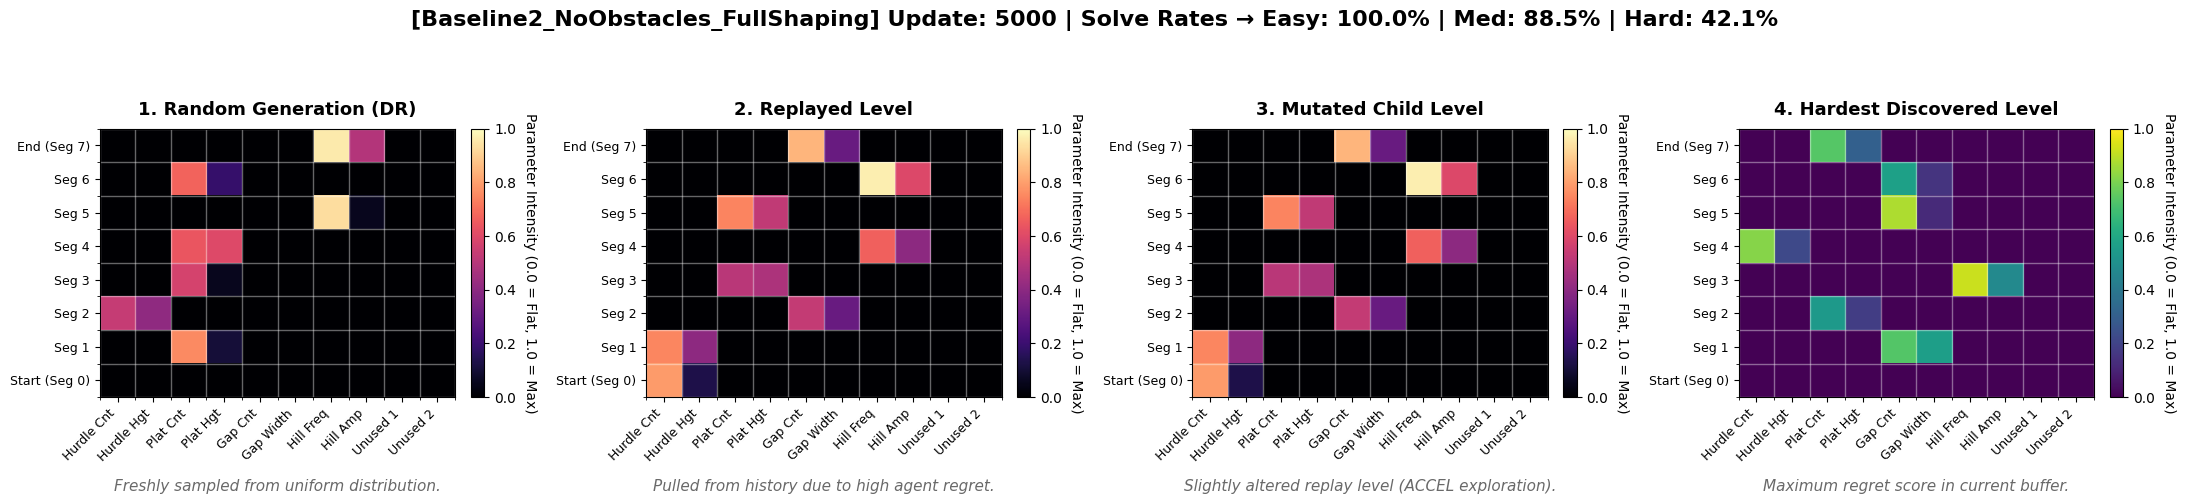

Logging update: 5000 | Mean Return: 992.40
--> Update 5000/5000 [100.0%] | Elapsed: 1:13:28 | ETA: 0:00:00
--> Saving mid-run backup at Update 5000...

Run Complete! Total Time: 1:13:28
Training complete! Generating final reports...
Raw metrics saved to: /content/drive/MyDrive/Go1_UED_Project_Final/Baseline2_NoObstacles_FullShaping_metrics.json


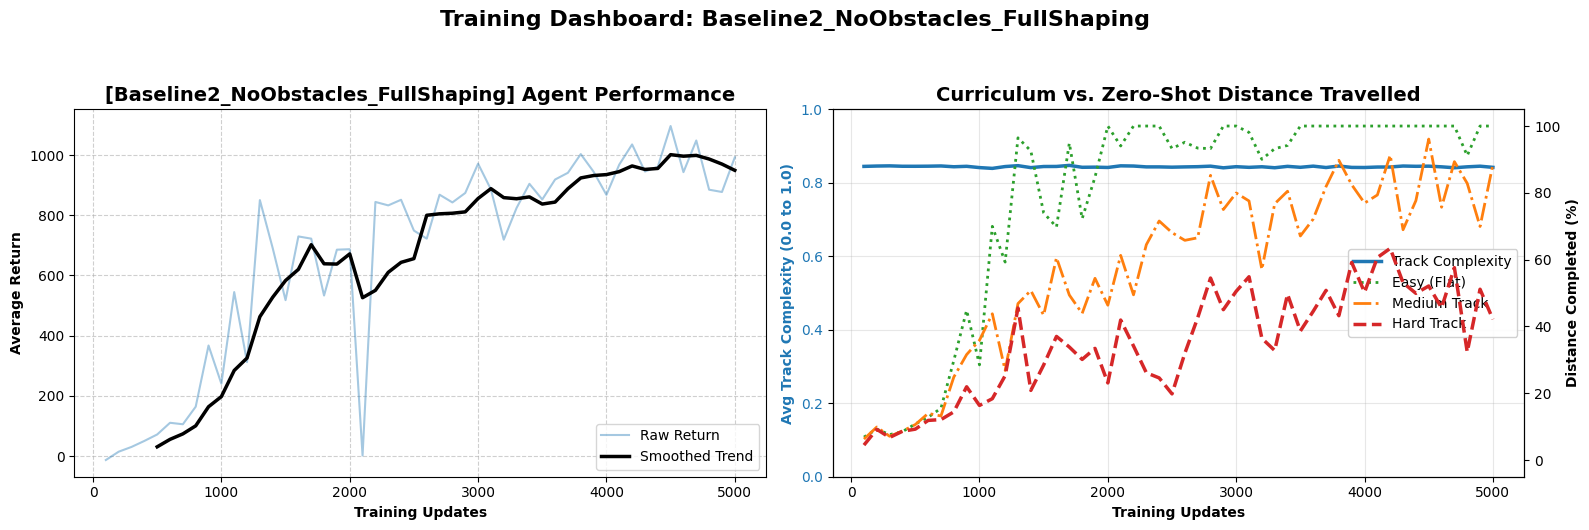

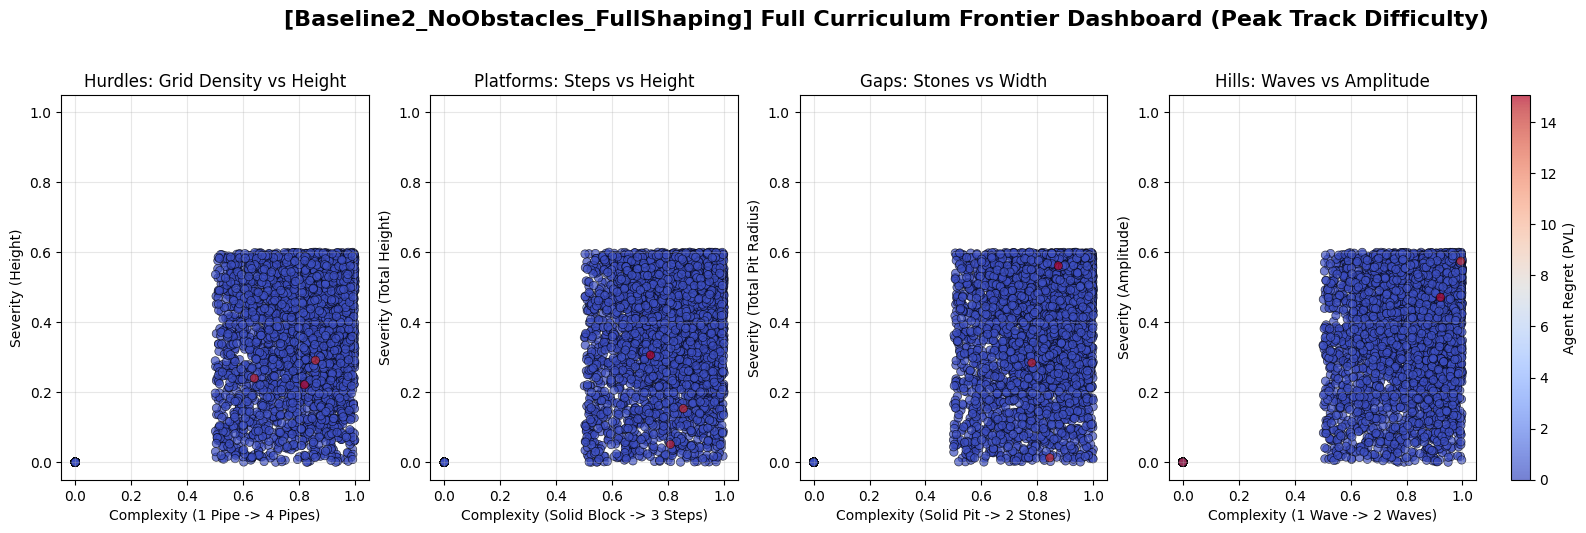

Saving policy weights to disk...
Success! Policy saved securely to: /content/drive/MyDrive/Go1_UED_Project_Final/Baseline2_NoObstacles_FullShaping_final_policy_ckpt
All reports saved to the 'ued_history' folder.


In [ ]:
# Kick off training!
current_run_name = run_config['run_name']
print(f"Starting run: {current_run_name}")
final_train_state, run_history = main(run_config)

print("Training complete! Generating final reports...")

# Save the raw numerical data to a JSON file
json_path = os.path.abspath(f"{SAVE_DIR}/{current_run_name}_metrics.json")
with open(json_path, 'w') as f:
    json.dump(run_history, f, indent=4)
print(f"Raw metrics saved to: {json_path}")

# Plot the learning curves
plot_local_learning_curves(run_history, run_name=current_run_name)
plot_curriculum_dashboard(final_train_state, run_name=current_run_name)

# Save the Neural Network Weights
print("Saving policy weights to disk...")
checkpoint_dir = os.path.abspath(f"{SAVE_DIR}/{current_run_name}_final_policy_ckpt")
# Create a standard JAX checkpointer
checkpointer = ocp.StandardCheckpointer()
# Save the entire train state (network weights, optimizer state, etc.)
# force=True overwrites any old checkpoint in that folder
checkpointer.save(checkpoint_dir, final_train_state, force=True)

print(f"Success! Policy saved securely to: {checkpoint_dir}")
print("All reports saved to the 'ued_history' folder.")

## Visualise policy

In [ ]:
def visualize_policy(train_state, blueprint, save_path=None, steps=250):
    print("Setting up the evaluation environment and rendering engine...")
    rng = jax.random.PRNGKey(42)
    rng_terrain, rng_reset = jax.random.split(rng)

    # Spin up a fresh environment locally
    base_env = DynamicJoystick(task="rough_terrain")

    env = Go1RoughUED(base_env, nrow=256, ncol=256)
    env_params = env.default_params
    mj_model = base_env.unwrapped.mj_model

    # 1. Generate the specific terrain array for this blueprint
    flat_hfield = env._generate_hfield(rng_terrain, blueprint)
    mj_model.hfield_data[:] = flat_hfield

    mj_data = mujoco.MjData(mj_model)

    # ---> CHANGED: Lowered resolution to save 70% RAM <---
    renderer = mujoco.Renderer(mj_model, height=360, width=640)
    camera = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(mj_model, camera)
    camera.distance = 7.0
    camera.elevation = -25
    camera.azimuth = 90

    # 3. Initialize Agent State
    obs, env_state = env.reset_to_level(rng_reset, blueprint, env_params)

    # ---> CHANGED: Initial Sync & Render (Catch the spawn frame!) <---
    mjx.get_data_into(mj_data, mj_model, env_state.base_state.data)
    mujoco.mj_forward(mj_model, mj_data)
    mujoco.mj_kinematics(mj_model, mj_data)
    camera.lookat[:] = mj_data.qpos[:3]
    renderer.update_scene(mj_data, camera=camera)

    # Start our video list with the exact moment of spawn
    frames = [renderer.render()]
    # -------------------------------------------------------------

    hstate = Go1ActorCritic.initialize_carry((1,))

    obs = jax.tree_util.tree_map(lambda x: x[None, None, ...], obs)
    dones = jnp.zeros((1, 1), dtype=bool)

    # frames = [] ## CHANGED -- UPDATED TO NOT LOSE 'STEP 0' WHERE THE ROBOT IS SPAWNED
    print(f"Simulating {steps} steps...")

    jit_step = jax.jit(env.step)

    for i in range(steps):
        rng, rng_action = jax.random.split(rng)

        # Forward pass through the trained network
        hstate, pi, _ = train_state.apply_fn(train_state.params, (obs, dones), hstate)
        action = pi.mean()[0, 0]

        # Step the environment
        obs, env_state, reward, done, info = jit_step(rng, env_state, action, env_params)

        obs = jax.tree_util.tree_map(lambda x: x[None, None, ...], obs)
        dones = jnp.array([[done]], dtype=bool)

        # Sync GPU physics state back to CPU for rendering
        mjx.get_data_into(mj_data, mj_model, env_state.base_state.data)
        mujoco.mj_kinematics(mj_model, mj_data)
        mujoco.mj_camlight(mj_model, mj_data)
        camera.lookat[:] = mj_data.qpos[:3]

        # ---> CHANGED: Frame Skipping (Record every 2nd step to halve memory) <---
        if i % 2 == 0:
            renderer.update_scene(mj_data, camera=camera)
            frames.append(renderer.render())

        if done:
            print(f"Episode finished early at step {i} (Robot likely fell!)")
            # ---> CHANGED: Freeze Frame padding <---
            # Duplicate the final crash frame 25 times (1 full second of video)
            # so the video doesn't instantly blink out of existence!
            for _ in range(25):
                frames.append(frames[-1])
            break
            break

    if save_path is not None:
        print(f"Saving video to {save_path}...")
        media.write_video(save_path, frames, fps=25)
        print("Save complete!")

    print("Rendering video...")
    # ---> CHANGED: Playback at 25 FPS to match the skipped frames <---
    media.show_video(frames, fps=25)

    # ---> CHANGED: Aggressively free up RAM after video displays <---
    del frames
    gc.collect()

In [ ]:
# --- POST-TRAINING RESTORATION ---
# Run this cell AFTER training finishes but BEFORE generating videos.
# This allows the visualizer to actually render the obstacles.

def restored_generate_hfield(self, key, blueprint):
    # ---> CHANGED: The ACCEL "Spawn-Kill" Protection <---
    # Forcefully overwrite Segment 0 to be perfectly flat (all zeros)
    # This guarantees the robot always spawns on safe ground!
    blueprint = blueprint.at[0].set(0.0)
    # ----------------------------------------------------
    low_res = blueprint_to_track(blueprint, key)

    row_scale = max(1, self.nrow // low_res.shape[0])
    col_scale = max(1, self.ncol // low_res.shape[1])
    terrain_scaled = jnp.kron(low_res, jnp.ones((row_scale, col_scale)))
    terrain_scaled = terrain_scaled[:self.nrow, :self.ncol]

    # Use the centralized variables!
    normalized = (terrain_scaled - self.z_min) / self.z_span
    return jnp.clip(normalized, 0.0, 1.0).T.flatten()

# Hot-patch the class so the environment instance used in visualization sees the obstacles
Go1RoughUED._generate_hfield = restored_generate_hfield

print("Terrain generation restored! Visualizer will now render the shortened obstacles.")

Terrain generation restored! Visualizer will now render the shortened obstacles.


## Loading saved policy

In [ ]:
# run your Setup Cell (with the imports and JAX monkey patch) and
# redefine your Go1ActorCritic and create_train_state functions before running this load script.

In [ ]:
import os
import jax
import orbax.checkpoint as ocp

# 1. Define the exact run name you want to load
run_to_load = "Baseline2_NoObstacles_FullShaping" # Change this to "DR_Baseline" to load the other one!

# 2. Point to that specific saved folder
checkpoint_dir = os.path.abspath(f"{SAVE_DIR}/{run_to_load}_final_policy_ckpt")
checkpointer = ocp.StandardCheckpointer()

print("1. Generating a blank structural state...")
# We give main() a dummy config that tells it to do ZERO training steps.
# It will initialize the network, skip the training loop, and hand us back the blank state!
dummy_config = run_config.copy()
dummy_config["num_updates"] = 0
blank_train_state, _ = main(dummy_config)

print("2. Restoring saved weights into the blank state...")
checkpointer = ocp.StandardCheckpointer()
loaded_train_state = checkpointer.restore(
    checkpoint_dir,
    blank_train_state
)
print(f"Policy '{run_to_load}' successfully loaded from disk!")

1. Generating a blank structural state...


Starting Training Loop for Baseline2_NoObstacles_FullShaping...

Run Complete! Total Time: 0:00:00
2. Restoring saved weights into the blank state...
Policy 'Baseline2_NoObstacles_FullShaping' successfully loaded from disk!


## Visualising saved policy

In [ ]:
# The "Parkour Qualification Course"
# Tests both pure athletic power (single obstacles) and dexterity (complex obstacles)
benchmark_track = (
    TrackBuilder(num_segments=8)
    # Seg 0: Flat ground (Warmup)

    # Seg 1: Double Hurdle (Agility)
    # prob=0.4 -> 2 distinct hurdles, height=0.6 -> 0.15m tall
    .add_hurdles(start_seg=4, end_seg=2, prob=0.4, height=0.6)

    # Seg 2: Rolling Hills (Pitch/Roll Stability)
    # prob=1.0 -> 2 waves, amp=0.6 -> 0.18m amplitude
    .add_hills(start_seg=2, end_seg=3, prob=1.0, amp=0.6)

    # Seg 3: The Vault (Athletic Climbing)
    # prob=0.0 -> 1 solid block (No stairs!), height=0.5 -> 0.17m high ledge
    .add_platforms(start_seg=0, end_seg=4, prob=0.0, height=0.5)

    # Seg 4: The Long Jump (Athletic Leaping)
    # prob=0.0 -> 1 solid pit (No stones!), width=0.5 -> ~0.1m wide gap
    .add_gaps(start_seg=3, end_seg=5, prob=0.0, width=0.5)

    # Seg 5: The Staircase (Dexterity & Foot Placement)
    # prob=1.0 -> 3-step pyramid, height=0.8 -> 0.28m total height
    .add_platforms(start_seg=5, end_seg=6, prob=1.0, height=0.8)

    # Seg 6: The Stepping Stone (Precision Target)
    # prob=0.5 -> 1 safe island in the middle, width=0.7 -> wider overall pit
    .add_gaps(start_seg=6, end_seg=7, prob=0.5, width=0.7)
    .build()
)

# save video
os.makedirs("ued_history", exist_ok=True)
video_path = os.path.abspath(f"{SAVE_DIR}/{current_run_name}_final_showcase.mp4")

# use if loading saved policy from below
final_train_state = loaded_train_state
current_run_name = run_to_load

# Render it (Make sure to give it enough steps to finish!)
# PARAMS: Increse steps to 200 -> 1500
visualize_policy(final_train_state, benchmark_track, video_path, steps=1500)

Setting up the evaluation environment and rendering engine...
Simulating 1500 steps...
Episode finished early at step 193 (Robot likely fell!)
Saving video to /content/drive/MyDrive/Go1_UED_Project_Final/Baseline2_NoObstacles_FullShaping_final_showcase.mp4...
Save complete!
Rendering video...


This browser does not support the video tag.


In [ ]:
flat_track = flat_track.at[7, 9].set(1.0)

# 1. Extract the Evaluation Levels from your config
# (These are the exact tracks plotted on your right-hand graph)
eval_levels = jnp.array(run_config["eval_levels"])

# 2. Select the track you want to see:
# index 0 = Easy (Flat)
# index 1 = Medium
# index 2 = Hard
track_idx = 0
benchmark_track = eval_levels[track_idx]

print(f"Rendering Benchmark Track {track_idx}...")

# 3. Visualize the current brain on the benchmark track!
video_path = os.path.abspath(f"{SAVE_DIR}/{current_run_name}_easy_track.mp4")
visualize_policy(final_train_state, flat_track, save_path=video_path, steps=1500)

Rendering Benchmark Track 0...
Setting up the evaluation environment and rendering engine...
Simulating 1500 steps...
Episode finished early at step 559 (Robot likely fell!)
Saving video to /content/drive/MyDrive/Go1_UED_Project_Final/Baseline2_NoObstacles_FullShaping_easy_track.mp4...
Save complete!
Rendering video...


This browser does not support the video tag.


In [ ]:
# 1. Extract the Evaluation Levels from your config
# (These are the exact tracks plotted on your right-hand graph)
eval_levels = jnp.array(run_config["eval_levels"])

# 2. Select the track you want to see:
# index 0 = Easy (Flat)
# index 1 = Medium
# index 2 = Hard
track_idx = 1
benchmark_track = eval_levels[track_idx]

print(f"Rendering Benchmark Track {track_idx}...")

# 3. Visualize the current brain on the benchmark track!
video_path = os.path.abspath(f"{SAVE_DIR}/{current_run_name}_medium_track.mp4")
visualize_policy(final_train_state, benchmark_track, save_path=video_path, steps=1500)

Rendering Benchmark Track 1...
Setting up the evaluation environment and rendering engine...
Simulating 1500 steps...
Episode finished early at step 184 (Robot likely fell!)
Saving video to /content/drive/MyDrive/Go1_UED_Project_Final/Baseline2_NoObstacles_FullShaping_medium_track.mp4...
Save complete!
Rendering video...


This browser does not support the video tag.


In [ ]:
# 1. Extract the Evaluation Levels from your config
# (These are the exact tracks plotted on your right-hand graph)
eval_levels = jnp.array(run_config["eval_levels"])

# 2. Select the track you want to see:
# index 0 = Easy (Flat)
# index 1 = Medium
# index 2 = Hard
track_idx = 2
benchmark_track = eval_levels[track_idx]

print(f"Rendering Benchmark Track {track_idx}...")

# 3. Visualize the current brain on the benchmark track!
video_path = os.path.abspath(f"{SAVE_DIR}/{current_run_name}_hard_track.mp4")
visualize_policy(final_train_state, benchmark_track, save_path=video_path, steps=1500)

Rendering Benchmark Track 2...
Setting up the evaluation environment and rendering engine...
Simulating 1500 steps...
Episode finished early at step 128 (Robot likely fell!)
Saving video to /content/drive/MyDrive/Go1_UED_Project_Final/Baseline2_NoObstacles_FullShaping_hard_track.mp4...
Save complete!
Rendering video...


This browser does not support the video tag.


## End runtime

In [ ]:
import time
from google.colab import runtime

# Give the backup cell a 30-second buffer to finish writing files to Drive
print("Training and Backup complete. Shutting down in 30 seconds to save credits...")
time.sleep(30)

# This is the "Kill Switch"
runtime.unassign()

Training and Backup complete. Shutting down in 30 seconds to save credits...


## TODO

- (done - partially) Get better visualisations for Curricula, instead of heatmaps
- Test environments easy/med/hard generate
- (done) update the 'eval_solve_rates' definition to include distance
- PPO network for baseline robot on flat surface should be same as this one?
- Initial seed for replay buffer: currently random, make it start with easy levels
- (done) Reduce the initial robot spawn height, and
- (done) change the starting postition to the beginning of the track
- (done - but not the same set as test) visualising the final policy: on easy, med, hard
- Ablation study with manually curated curriculum
- Add other hurdles to the Level Regret scatter plot
- Add some metrics during train time to see how the robot is doing in its latest best run - e.g. how much distance it is covering, what is the height/gap of the place where it faltered, etc.

**Notes**
- (done) Finish Line:
  - for small train: Finish at -11, a 7 meter track, max step 250
  - for final run: Finish at +16, 34 meter track, increase max_steps_in_episode and max_steps_per_episode to 100 to give robot 20 secs to finish the course
- (done) The first meter or two where the robot is spawned should be flat surface. We should only add hurdles after that
- changes in CHANGED, # PARAMS to keep track of parameters to change during training runs